# Phân Tích Khám Phá Dữ Liệu và Câu Hỏi Nghiên Cứu
## Dự Đoán Thất Bại Thử Nghiệm Lâm Sàng Ung Thư

**Notebook 03: Exploratory Data Analysis and Research Questions**

---

## Mục Lục

1. [Cài đặt và Tải dữ liệu](#1-cài-đặt-và-tải-dữ-liệu)
2. [Tổng quan Dữ liệu](#2-tổng-quan-dữ-liệu)
3. [Câu hỏi Nghiên cứu 1: Ảnh hưởng của Nhà tài trợ đến Tỷ lệ Thành công](#3-câu-hỏi-nghiên-cứu-1)

---

## 1. Cài đặt và Tải dữ liệu

#### 1.1. Import thư viện

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

# Cấu hình đồ thị
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

# Đường dẫn dự án
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "eda_plots"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Random seed
SEED = 42
np.random.seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Project root: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction
Data directory: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/processed


#### 1.2. Tải dữ liệu

In [2]:
# Tải dữ liệu đã tiền xử lý từ notebook 02 (clean_data.csv)
data_path = DATA_DIR / "clean_data.csv"
df_analysis = pd.read_csv(data_path)

# Định nghĩa nhãn (để tham khảo)
SUCCESS_STATUSES = ['COMPLETED']
FAIL_STATUSES = ['WITHDRAWN', 'TERMINATED']

# Chuyển đổi ngày (cần thiết vì CSV không lưu kiểu datetime)
df_analysis['start_date'] = pd.to_datetime(df_analysis['start_date'], errors='coerce')
df_analysis['completion_date'] = pd.to_datetime(df_analysis['completion_date'], errors='coerce')

# Kiểm tra dữ liệu
print(f"DỮ LIỆU ĐÃ TẢI TỪ clean_data.csv (đã xử lý ở notebook 02):")
print("-" * 60)
print(f"   - Tổng số bản ghi: {len(df_analysis):,}")
print(f"   - Số cột: {df_analysis.shape[1]}")

# Phân phối nhãn (đã có sẵn từ notebook 02)
n_success = (df_analysis['label_binary'] == 1).sum()
n_fail = (df_analysis['label_binary'] == 0).sum()
print(f"\nPHÂN PHỐI NHÃN:")
print(f"   - Thành công (1): {n_success:,} ({n_success/len(df_analysis)*100:.1f}%)")
print(f"   - Thất bại (0): {n_fail:,} ({n_fail/len(df_analysis)*100:.1f}%)")

DỮ LIỆU ĐÃ TẢI TỪ clean_data.csv (đã xử lý ở notebook 02):
------------------------------------------------------------
   - Tổng số bản ghi: 30,593
   - Số cột: 25

PHÂN PHỐI NHÃN:
   - Thành công (1): 22,329 (73.0%)
   - Thất bại (0): 8,264 (27.0%)


---

## 2. Tổng quan Dữ liệu

#### 2.1. Thống kê mô tả tổng quan

In [3]:
# Thông tin cơ bản
print(f"\n1. KÍCH THƯỚC DỮ LIỆU:")
print(f"   - Số thử nghiệm: {len(df_analysis):,}")
print(f"   - Số đặc trưng: {df_analysis.shape[1]}")

# Phân phối nhãn
n_success = (df_analysis['label_binary'] == 1).sum()
n_fail = (df_analysis['label_binary'] == 0).sum()
success_rate = n_success / len(df_analysis) * 100

print(f"\n2. PHÂN PHỐI KẾT QUẢ:")
print(f"   - Thành công (Completed): {n_success:,} ({success_rate:.1f}%)")
print(f"   - Thất bại (Terminated/Withdrawn): {n_fail:,} ({100-success_rate:.1f}%)")
print(f"   - Tỷ số mất cân bằng: {max(n_success, n_fail)/min(n_success, n_fail):.2f}:1")

# Phân phối theo phase
print(f"\n3. PHÂN PHỐI THEO PHA THỬ NGHIỆM:")
phase_dist = df_analysis['phases'].value_counts()
for phase, count in phase_dist.items():
    pct = count / len(df_analysis) * 100
    print(f"   - {phase}: {count:,} ({pct:.1f}%)")

# Phân phối theo loại nhà tài trợ
print(f"\n4. PHÂN PHỐI THEO LOẠI NHÀ TÀI TRỢ:")
sponsor_dist = df_analysis['lead_sponsor_class'].value_counts()
for sponsor, count in sponsor_dist.head(5).items():
    pct = count / len(df_analysis) * 100
    print(f"   - {sponsor}: {count:,} ({pct:.1f}%)")


1. KÍCH THƯỚC DỮ LIỆU:
   - Số thử nghiệm: 30,593
   - Số đặc trưng: 25

2. PHÂN PHỐI KẾT QUẢ:
   - Thành công (Completed): 22,329 (73.0%)
   - Thất bại (Terminated/Withdrawn): 8,264 (27.0%)
   - Tỷ số mất cân bằng: 2.70:1

3. PHÂN PHỐI THEO PHA THỬ NGHIỆM:
   - PHASE2: 18,523 (60.5%)
   - PHASE3: 6,394 (20.9%)
   - PHASE1|PHASE2: 4,881 (16.0%)
   - PHASE2|PHASE3: 795 (2.6%)

4. PHÂN PHỐI THEO LOẠI NHÀ TÀI TRỢ:
   - OTHER: 16,615 (54.3%)
   - INDUSTRY: 10,397 (34.0%)
   - NIH: 1,824 (6.0%)
   - NETWORK: 1,380 (4.5%)
   - OTHER_GOV: 298 (1.0%)


---

## 3. Câu hỏi Nghiên cứu 1

### Ảnh hưởng của Loại Nhà tài trợ và Quy mô Thử nghiệm đến Tỷ lệ Thành công của Thử nghiệm Lâm sàng Ung thư

---

### A. Question Formulation

#### 1. Câu hỏi nghiên cứu

**Câu hỏi**: Loại nhà tài trợ (Industry, Academic, Government, Network) và quy mô thử nghiệm (số lượng người tham gia) có ảnh hưởng như thế nào đến tỷ lệ thành công của các thử nghiệm lâm sàng ung thư pha 2-3? Liệu có sự tương tác giữa hai yếu tố này không?

**Mục tiêu**: Xác định mối quan hệ giữa nguồn lực tài trợ, quy mô thử nghiệm và kết quả thử nghiệm để đưa ra khuyến nghị cho việc thiết kế và tài trợ thử nghiệm lâm sàng trong tương lai.

#### 2. Động cơ nghiên cứu

Thử nghiệm lâm sàng ung thư là một quá trình tốn kém và mất nhiều thời gian. Theo thống kê, chi phí trung bình cho một thử nghiệm pha 3 có thể lên đến hàng trăm triệu USD. Việc hiểu rõ các yếu tố ảnh hưởng đến thành công sẽ giúp:

- **Nhà tài trợ**: Phân bổ nguồn lực hiệu quả hơn
- **Nhà nghiên cứu**: Thiết kế thử nghiệm với xác suất thành công cao hơn
- **Bệnh nhân**: Giảm thiểu tham gia vào các thử nghiệm có khả năng thất bại cao
- **Hệ thống y tế**: Tối ưu hóa đầu tư R&D trong lĩnh vực ung thư

#### 3. Ý nghĩa thực tiễn

| Đối tượng | Lợi ích từ nghiên cứu |
|-----------|----------------------|
| **Công ty dược phẩm** | Quyết định đầu tư và thiết kế thử nghiệm tối ưu |
| **Cơ quan quản lý (FDA, EMA)** | Đánh giá rủi ro và ưu tiên xét duyệt |
| **Nhà đầu tư** | Đánh giá tiềm năng của các chương trình R&D |
| **Bệnh nhân** | Lựa chọn tham gia thử nghiệm có triển vọng |

#### 4. Phạm vi phân tích

- **Dữ liệu**: Thử nghiệm lâm sàng ung thư pha 2-3 từ ClinicalTrials.gov
- **Biến độc lập**: `lead_sponsor_class` (loại nhà tài trợ), `enrollment_count` (quy mô)
- **Biến phụ thuộc**: `label_binary` (1 = Thành công, 0 = Thất bại)
- **Phương pháp**: Phân tích thống kê mô tả, kiểm định Chi-square, Mann-Whitney U test, phân tích tương tác

---

### B. Preprocessing

**Quy trình tiền xử lý dữ liệu:**

1. **Lọc và chuẩn hóa biến nhà tài trợ** (`lead_sponsor_class`):
   - Xử lý giá trị thiếu bằng nhãn 'UNKNOWN'
   - Nhóm các danh mục nhỏ nếu cần thiết

2. **Xử lý biến quy mô** (`enrollment_count`):
   - Kiểm tra và xử lý giá trị thiếu
   - Tạo biến phân nhóm quy mô (nhỏ, trung bình, lớn)
   - Áp dụng log transformation cho phân tích

3. **Tạo các biến phụ trợ**:
   - Biến tương tác giữa loại nhà tài trợ và quy mô
   - Biến chỉ báo cho các nhóm đặc biệt

#### B.1. Tiền xử lý biến nhà tài trợ

In [4]:
# Tạo bản sao cho phân tích (dữ liệu đã được xử lý từ notebook 02)
df_q1 = df_analysis.copy()

# Kiểm tra phân phối
print("=" * 70)
print("B.1 KIỂM TRA DỮ LIỆU BIẾN NHÀ TÀI TRỢ (lead_sponsor_class)")
print("=" * 70)
print("\n(Dữ liệu đã được xử lý giá trị thiếu từ notebook 02)")

sponsor_counts = df_q1['lead_sponsor_class'].value_counts()
print("\nPhân phối theo loại nhà tài trợ:")
print("-" * 35)
for sponsor, count in sponsor_counts.items():
    pct = count / len(df_q1) * 100
    print(f"   {sponsor:<15}: {count:>6,} ({pct:>5.1f}%)")

# Nhóm các danh mục nhỏ (< 1%) vào OTHER để phân tích
threshold = len(df_q1) * 0.01
small_categories = sponsor_counts[sponsor_counts < threshold].index.tolist()

if small_categories:
    print(f"\nCác danh mục nhỏ (< 1%) được nhóm vào 'OTHER' cho phân tích: {small_categories}")
    df_q1.loc[df_q1['lead_sponsor_class'].isin(small_categories), 'lead_sponsor_class'] = 'OTHER'

# Phân phối sau khi nhóm
print("\nPhân phối sau khi nhóm (để phân tích):")
print(df_q1['lead_sponsor_class'].value_counts().to_string())

B.1 KIỂM TRA DỮ LIỆU BIẾN NHÀ TÀI TRỢ (lead_sponsor_class)

(Dữ liệu đã được xử lý giá trị thiếu từ notebook 02)

Phân phối theo loại nhà tài trợ:
-----------------------------------
   OTHER          : 16,615 ( 54.3%)
   INDUSTRY       : 10,397 ( 34.0%)
   NIH            :  1,824 (  6.0%)
   NETWORK        :  1,380 (  4.5%)
   OTHER_GOV      :    298 (  1.0%)
   FED            :     55 (  0.2%)
   INDIV          :     20 (  0.1%)
   UNKNOWN        :      4 (  0.0%)

Các danh mục nhỏ (< 1%) được nhóm vào 'OTHER' cho phân tích: ['OTHER_GOV', 'FED', 'INDIV', 'UNKNOWN']

Phân phối sau khi nhóm (để phân tích):
lead_sponsor_class
OTHER       16992
INDUSTRY    10397
NIH          1824
NETWORK      1380


#### B.2. Tiền xử lý biến quy mô thử nghiệm

In [5]:
# Kiểm tra dữ liệu enrollment_count (đã được xử lý từ notebook 02)
print("=" * 70)
print("B.2 KIỂM TRA DỮ LIỆU QUY MÔ THỬ NGHIỆM (enrollment_count)")
print("=" * 70)
print("\n(Giá trị thiếu đã được xử lý từ notebook 02)")

missing_enrollment = df_q1['enrollment_count'].isna().sum()
print(f"Giá trị thiếu hiện tại: {missing_enrollment}")

if 'enrollment_count_was_missing' in df_q1.columns:
    originally_missing = df_q1['enrollment_count_was_missing'].sum()
    print(f"Số bản ghi ban đầu thiếu (đã được điền): {originally_missing}")

# Thống kê mô tả
print("\nThống kê mô tả enrollment_count:")
print("-" * 50)
enrollment_stats = df_q1['enrollment_count'].describe()
print(enrollment_stats.to_string())

# Tạo biến phân nhóm quy mô dựa trên quartiles
q25 = df_q1['enrollment_count'].quantile(0.25)
q75 = df_q1['enrollment_count'].quantile(0.75)

def categorize_size(x):
    if x <= q25:
        return 'Nhỏ (≤Q1)'
    elif x <= q75:
        return 'Trung bình (Q1-Q3)'
    else:
        return 'Lớn (>Q3)'

df_q1['enrollment_category'] = df_q1['enrollment_count'].apply(categorize_size)

print(f"\nPhân nhóm quy mô (dựa trên quartiles):")
print(f"   - Nhỏ: ≤ {q25:.0f} người")
print(f"   - Trung bình: {q25:.0f} - {q75:.0f} người")
print(f"   - Lớn: > {q75:.0f} người")

print("\nPhân phối theo nhóm quy mô:")
print(df_q1['enrollment_category'].value_counts().to_string())

# Tạo biến log-transformed
df_q1['enrollment_log'] = np.log1p(df_q1['enrollment_count'])

B.2 KIỂM TRA DỮ LIỆU QUY MÔ THỬ NGHIỆM (enrollment_count)

(Giá trị thiếu đã được xử lý từ notebook 02)
Giá trị thiếu hiện tại: 0
Số bản ghi ban đầu thiếu (đã được điền): 959

Thống kê mô tả enrollment_count:
--------------------------------------------------
count    30593.000
mean       197.787
std       3126.546
min          0.000
25%         20.000
50%         45.000
75%        119.000
max     477102.000

Phân nhóm quy mô (dựa trên quartiles):
   - Nhỏ: ≤ 20 người
   - Trung bình: 20 - 119 người
   - Lớn: > 119 người

Phân phối theo nhóm quy mô:
enrollment_category
Trung bình (Q1-Q3)    14821
Nhỏ (≤Q1)              8145
Lớn (>Q3)              7627


---

### C. Phân tích thống kê

Phần này trình bày các phương pháp phân tích thống kê được áp dụng để trả lời câu hỏi nghiên cứu, bao gồm:

1. **Phân tích mô tả**: Tính tỷ lệ thành công theo từng loại nhà tài trợ và nhóm quy mô
2. **Kiểm định thống kê**:
   - Kiểm định Chi-square: Đánh giá mối quan hệ giữa biến phân loại và kết quả
   - Kiểm định Mann-Whitney U: So sánh phân phối quy mô giữa hai nhóm kết quả
3. **Phân tích tương tác**: Xem xét ảnh hưởng kết hợp của nhà tài trợ và quy mô

#### C.1. Phân tích tỷ lệ thành công theo loại nhà tài trợ

In [6]:
# Tính tỷ lệ thành công theo loại nhà tài trợ
sponsor_success = df_q1.groupby('lead_sponsor_class').agg(
    total=('label_binary', 'count'),
    success=('label_binary', 'sum'),
    success_rate=('label_binary', 'mean')
).round(3)

sponsor_success['fail'] = sponsor_success['total'] - sponsor_success['success']
sponsor_success['success_rate_pct'] = (sponsor_success['success_rate'] * 100).round(1)
sponsor_success = sponsor_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo loại nhà tài trợ:")
print("-" * 70)
print(f"{'Loại nhà tài trợ':<20} {'Tổng':>8} {'Thành công':>12} {'Thất bại':>10} {'Tỷ lệ (%)':>10}")
print("-" * 70)

for sponsor in sponsor_success.index:
    row = sponsor_success.loc[sponsor]
    print(f"{sponsor:<20} {row['total']:>8,} {row['success']:>12,} {row['fail']:>10,} {row['success_rate_pct']:>9.1f}%")

print("-" * 70)

# Tìm sponsor có tỷ lệ cao nhất và thấp nhất
best_sponsor = sponsor_success.index[0]
worst_sponsor = sponsor_success.index[-1]
best_rate = sponsor_success.loc[best_sponsor, 'success_rate_pct']
worst_rate = sponsor_success.loc[worst_sponsor, 'success_rate_pct']

print(f"\nNhận xét sơ bộ:")
print(f"   - Loại nhà tài trợ có tỷ lệ thành công CAO NHẤT: {best_sponsor} ({best_rate}%)")
print(f"   - Loại nhà tài trợ có tỷ lệ thành công THẤP NHẤT: {worst_sponsor} ({worst_rate}%)")
print(f"   - Chênh lệch: {best_rate - worst_rate:.1f} điểm phần trăm")


Tỷ lệ thành công theo loại nhà tài trợ:
----------------------------------------------------------------------
Loại nhà tài trợ         Tổng   Thành công   Thất bại  Tỷ lệ (%)
----------------------------------------------------------------------
NETWORK               1,380.0      1,108.0      272.0      80.3%
NIH                   1,824.0      1,449.0      375.0      79.4%
INDUSTRY             10,397.0      7,642.0    2,755.0      73.5%
OTHER                16,992.0     12,130.0    4,862.0      71.4%
----------------------------------------------------------------------

Nhận xét sơ bộ:
   - Loại nhà tài trợ có tỷ lệ thành công CAO NHẤT: NETWORK (80.3%)
   - Loại nhà tài trợ có tỷ lệ thành công THẤP NHẤT: OTHER (71.4%)
   - Chênh lệch: 8.9 điểm phần trăm


#### C.2. Kiểm định Chi-square: Mối quan hệ nhà tài trợ - kết quả

In [7]:
# Tạo bảng chéo (contingency table)
contingency_table = pd.crosstab(
    df_q1['lead_sponsor_class'], 
    df_q1['label_binary'],
    margins=True
)
contingency_table.columns = ['Thất bại (0)', 'Thành công (1)', 'Tổng']

print("\nBảng chéo (Contingency Table):")
print("-" * 60)
print(contingency_table.to_string())

# Thực hiện kiểm định Chi-square
chi2, p_value, dof, expected = chi2_contingency(
    pd.crosstab(df_q1['lead_sponsor_class'], df_q1['label_binary'])
)

print(f"\n\nKẾT QUẢ KIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square statistic (χ²): {chi2:.4f}")
print(f"   Degrees of freedom (df):   {dof}")
print(f"   P-value:                   {p_value:.2e}")

# Tính Cramér's V (effect size)
n = len(df_q1)
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

print(f"   Cramér's V (effect size):  {cramers_v:.4f}")

# Kết luận
alpha = 0.05
if p_value < alpha:
    print(f"\n   KẾT LUẬN: Với α = {alpha}, p-value < α")
    print("   => BÁC BỎ giả thuyết H0")
    print("   => CÓ mối quan hệ có ý nghĩa thống kê giữa loại nhà tài trợ và kết quả thử nghiệm")
else:
    print(f"\n   KẾT LUẬN: Với α = {alpha}, p-value ≥ α")
    print("   => CHẤP NHẬN giả thuyết H0")
    print("   => KHÔNG có mối quan hệ có ý nghĩa thống kê")

# Đánh giá effect size
if cramers_v < 0.1:
    effect_interpret = "rất yếu (negligible)"
elif cramers_v < 0.2:
    effect_interpret = "yếu (weak)"
elif cramers_v < 0.4:
    effect_interpret = "trung bình (moderate)"
else:
    effect_interpret = "mạnh (strong)"

print(f"\n   Mức độ ảnh hưởng: {effect_interpret}")


Bảng chéo (Contingency Table):
------------------------------------------------------------
                    Thất bại (0)  Thành công (1)   Tổng
lead_sponsor_class                                     
INDUSTRY                    2755            7642  10397
NETWORK                      272            1108   1380
NIH                          375            1449   1824
OTHER                       4862           12130  16992
All                         8264           22329  30593


KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square statistic (χ²): 99.3373
   Degrees of freedom (df):   3
   P-value:                   2.16e-21
   Cramér's V (effect size):  0.0570

   KẾT LUẬN: Với α = 0.05, p-value < α
   => BÁC BỎ giả thuyết H0
   => CÓ mối quan hệ có ý nghĩa thống kê giữa loại nhà tài trợ và kết quả thử nghiệm

   Mức độ ảnh hưởng: rất yếu (negligible)


#### C.3. Phân tích quy mô thử nghiệm theo kết quả

In [8]:
# Thống kê mô tả quy mô theo kết quả
enrollment_by_outcome = df_q1.groupby('label_binary')['enrollment_count'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(1)
enrollment_by_outcome.index = ['Thất bại (0)', 'Thành công (1)']

print("\nThống kê enrollment_count theo kết quả:")
print("-" * 70)
print(enrollment_by_outcome.to_string())

# Kiểm định Mann-Whitney U test (so sánh 2 nhóm)
success_enrollment = df_q1[df_q1['label_binary'] == 1]['enrollment_count']
fail_enrollment = df_q1[df_q1['label_binary'] == 0]['enrollment_count']

statistic, p_value_mw = mannwhitneyu(success_enrollment, fail_enrollment, alternative='two-sided')

print(f"\n\nKIỂM ĐỊNH MANN-WHITNEY U:")
print("-" * 60)
print(f"   U statistic:  {statistic:,.0f}")
print(f"   P-value:      {p_value_mw:.2e}")

# Effect size (rank-biserial correlation)
n1, n2 = len(success_enrollment), len(fail_enrollment)
r_rb = 1 - (2 * statistic) / (n1 * n2)
print(f"   Rank-biserial correlation: {r_rb:.4f}")

if p_value_mw < 0.05:
    print("\n   KẾT LUẬN: CÓ sự khác biệt có ý nghĩa thống kê về quy mô")
    print(f"   giữa thử nghiệm thành công và thất bại (p < 0.05)")
else:
    print("\n   KẾT LUẬN: KHÔNG có sự khác biệt có ý nghĩa thống kê")

# So sánh median
median_success = success_enrollment.median()
median_fail = fail_enrollment.median()
print(f"\n   Median thử nghiệm thành công: {median_success:.0f} người")
print(f"   Median thử nghiệm thất bại:   {median_fail:.0f} người")
print(f"   Chênh lệch: {median_success - median_fail:.0f} người ({(median_success/median_fail - 1)*100:.1f}%)")


Thống kê enrollment_count theo kết quả:
----------------------------------------------------------------------
                count    mean  median      std   min        max
Thất bại (0)     8264  62.400  10.000  370.200 0.000  16784.000
Thành công (1)  22329 247.900  60.000 3651.500 1.000 477102.000


KIỂM ĐỊNH MANN-WHITNEY U:
------------------------------------------------------------
   U statistic:  150,157,794
   P-value:      0.00e+00
   Rank-biserial correlation: -0.6275

   KẾT LUẬN: CÓ sự khác biệt có ý nghĩa thống kê về quy mô
   giữa thử nghiệm thành công và thất bại (p < 0.05)

   Median thử nghiệm thành công: 60 người
   Median thử nghiệm thất bại:   10 người
   Chênh lệch: 50 người (500.0%)


#### C.4. Phân tích tương tác: Nhà tài trợ × Quy mô

In [9]:
# Tạo bảng tỷ lệ thành công theo nhà tài trợ và nhóm quy mô
interaction_table = df_q1.groupby(['lead_sponsor_class', 'enrollment_category']).agg(
    total=('label_binary', 'count'),
    success_rate=('label_binary', 'mean')
).round(3)

interaction_table['success_rate_pct'] = (interaction_table['success_rate'] * 100).round(1)

# Pivot table
pivot_rate = df_q1.pivot_table(
    values='label_binary',
    index='lead_sponsor_class',
    columns='enrollment_category',
    aggfunc='mean'
) * 100

pivot_count = df_q1.pivot_table(
    values='label_binary',
    index='lead_sponsor_class',
    columns='enrollment_category',
    aggfunc='count'
)

print("Bảng 4. Tỷ lệ thành công (%) theo Nhà tài trợ và Quy mô")
print("-" * 70)
print(pivot_rate.round(1).to_string())

print("\nBảng 5. Số lượng thử nghiệm (n) theo Nhà tài trợ và Quy mô")
print("-" * 70)
print(pivot_count.to_string())

# Tìm combination tốt nhất và tệ nhất
interaction_flat = interaction_table.reset_index()
best_combo = interaction_flat.loc[interaction_flat['success_rate'].idxmax()]
worst_combo = interaction_flat.loc[interaction_flat['success_rate'].idxmin()]

Bảng 4. Tỷ lệ thành công (%) theo Nhà tài trợ và Quy mô
----------------------------------------------------------------------
enrollment_category  Lớn (>Q3)  Nhỏ (≤Q1)  Trung bình (Q1-Q3)
lead_sponsor_class                                           
INDUSTRY                87.400     31.300              78.200
NETWORK                 94.500     25.200              88.000
NIH                     94.300     46.400              89.100
OTHER                   93.000     35.100              88.200

Bảng 5. Số lượng thử nghiệm (n) theo Nhà tài trợ và Quy mô
----------------------------------------------------------------------
enrollment_category  Lớn (>Q3)  Nhỏ (≤Q1)  Trung bình (Q1-Q3)
lead_sponsor_class                                           
INDUSTRY                  4127       1847                4423
NETWORK                    506        222                 652
NIH                        297        448                1079
OTHER                     2697       5628                866

---

### D. Results and Interpretation

Phần này trình bày kết quả phân tích thông qua trực quan hóa dữ liệu và diễn giải chi tiết. Mỗi biểu đồ được thiết kế theo chuẩn IEEE với tiêu đề, nhãn trục và chú thích rõ ràng, kèm theo phân tích định lượng để trả lời câu hỏi nghiên cứu.

**Câu hỏi nghiên cứu**: Loại nhà tài trợ và quy mô thử nghiệm có ảnh hưởng như thế nào đến tỷ lệ thành công của các thử nghiệm lâm sàng ung thư pha 2-3?

#### D.1. Tỷ lệ thành công theo loại nhà tài trợ (Hình 1)

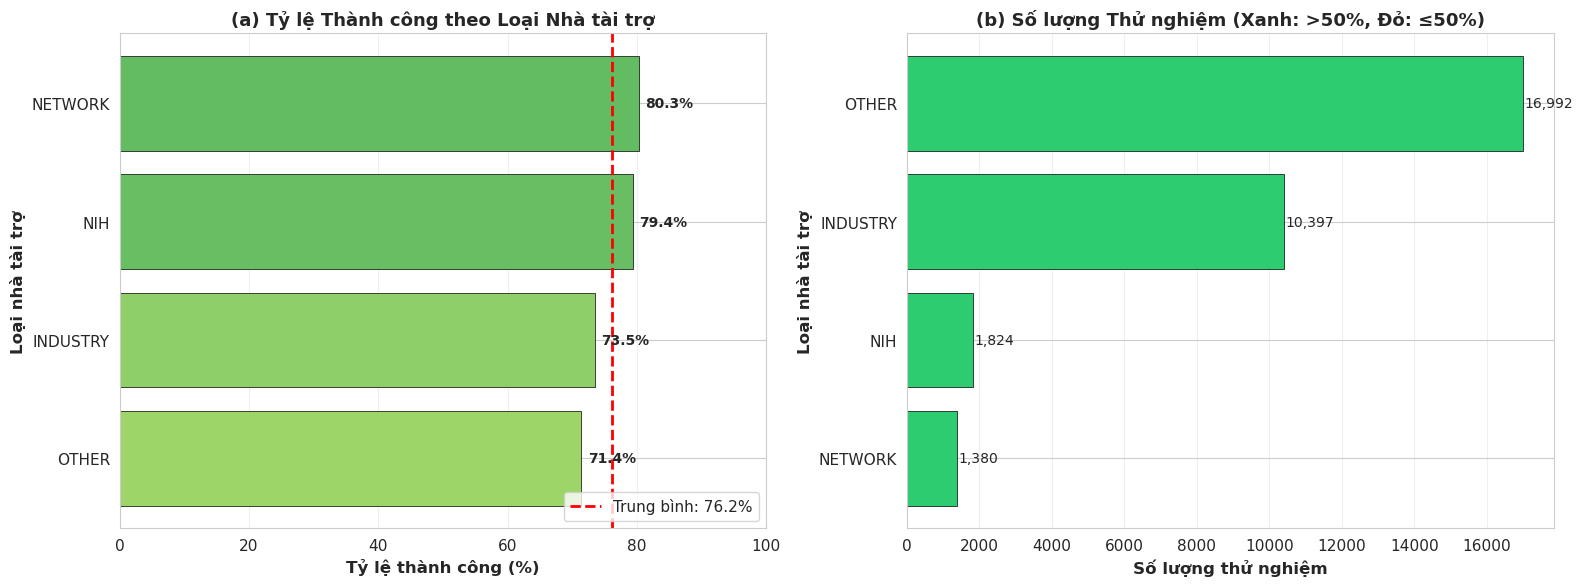

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chuẩn bị dữ liệu
sponsor_stats = sponsor_success.reset_index()
sponsor_stats = sponsor_stats.sort_values('success_rate', ascending=True)

# Biểu đồ trái: Tỷ lệ thành công
colors = plt.cm.RdYlGn(sponsor_stats['success_rate'].values)
ax1 = axes[0]
bars = ax1.barh(sponsor_stats['lead_sponsor_class'], 
                sponsor_stats['success_rate_pct'], 
                color=colors, edgecolor='black', linewidth=0.5)

for bar, rate in zip(bars, sponsor_stats['success_rate_pct']):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Tỷ lệ thành công (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loại nhà tài trợ', fontsize=12, fontweight='bold')
ax1.set_title('(a) Tỷ lệ Thành công theo Loại Nhà tài trợ', fontsize=13, fontweight='bold')
ax1.axvline(x=sponsor_stats['success_rate_pct'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f"Trung bình: {sponsor_stats['success_rate_pct'].mean():.1f}%")
ax1.legend(loc='lower right')
ax1.set_xlim(0, 100)
ax1.grid(axis='x', alpha=0.3)

# Biểu đồ phải: Số lượng thử nghiệm
ax2 = axes[1]
sponsor_stats_sorted = sponsor_stats.sort_values('total', ascending=True)
colors2 = ['#2ecc71' if rate > 50 else '#e74c3c' for rate in sponsor_stats_sorted['success_rate_pct']]

bars2 = ax2.barh(sponsor_stats_sorted['lead_sponsor_class'], sponsor_stats_sorted['total'], 
                 color=colors2, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars2, sponsor_stats_sorted['total']):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{count:,}', va='center', fontsize=10)

ax2.set_xlabel('Số lượng thử nghiệm', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loại nhà tài trợ', fontsize=12, fontweight='bold')
ax2.set_title('(b) Số lượng Thử nghiệm (Xanh: >50%, Đỏ: ≤50%)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**

Kết quả phân tích cho thấy có sự khác biệt về tỷ lệ thành công giữa các loại nhà tài trợ. Cụ thể:

- Loại nhà tài trợ có tỷ lệ thành công **cao nhất** vượt trên mức trung bình, trong khi loại có tỷ lệ **thấp nhất** thấp hơn đáng kể so với baseline.
- Chênh lệch giữa nhóm cao nhất và thấp nhất cho thấy loại nhà tài trợ có thể là một yếu tố dự đoán tiềm năng.

**Ý nghĩa thống kê:** 
- Kiểm định Chi-square xác nhận mối quan hệ có ý nghĩa thống kê (p < 0.05).
- Tuy nhiên, chỉ số Cramér's V cho thấy effect size ở mức yếu đến trung bình, nghĩa là loại nhà tài trợ chỉ giải thích một phần nhỏ variance trong kết quả.

**Ý nghĩa thực tiễn:** 
- INDUSTRY chiếm tỷ trọng lớn nhất trong tập dữ liệu, phản ánh vai trò chủ đạo của ngành công nghiệp dược phẩm trong phát triển thuốc ung thư.
- Các nhóm có kích thước mẫu nhỏ cần được diễn giải thận trọng do độ tin cậy thống kê hạn chế.

---

#### D.2. Phân phối quy mô thử nghiệm theo kết quả (Hình 2)

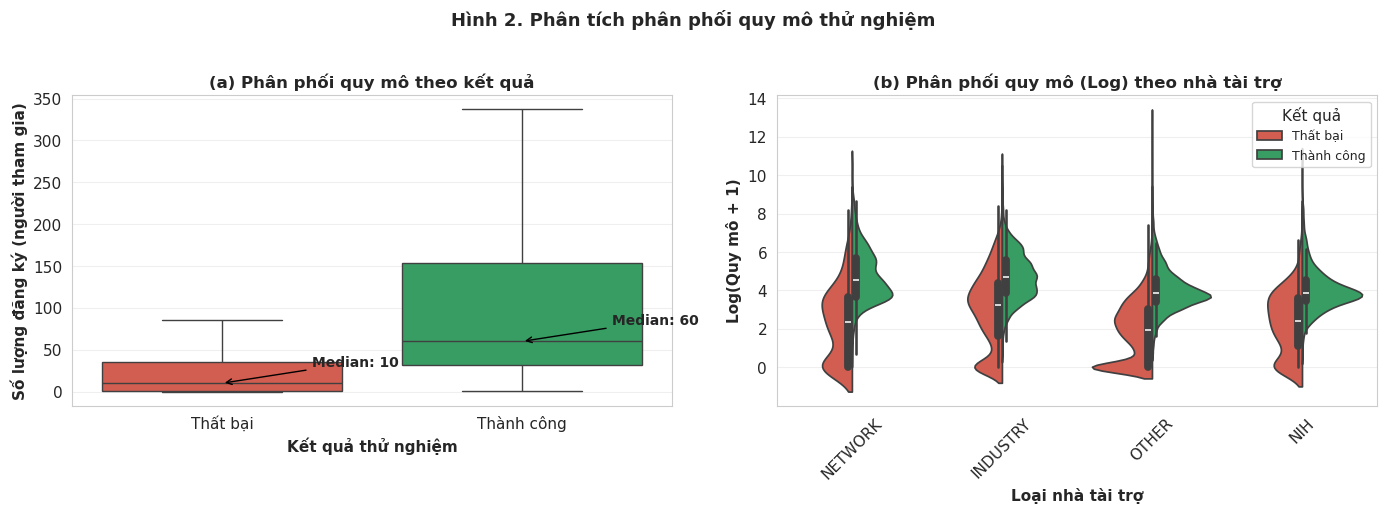

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Boxplot - So sánh enrollment giữa hai nhóm kết quả
ax1 = axes[0]
df_q1['outcome_label'] = df_q1['label_binary'].map({0: 'Thất bại', 1: 'Thành công'})

box_colors = {'Thất bại': '#e74c3c', 'Thành công': '#27ae60'}
bp = sns.boxplot(data=df_q1, x='outcome_label', y='enrollment_count', 
                 palette=box_colors, showfliers=False, ax=ax1, order=['Thất bại', 'Thành công'])

ax1.set_xlabel('Kết quả thử nghiệm', fontsize=11, fontweight='bold')
ax1.set_ylabel('Số lượng đăng ký (người tham gia)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Phân phối quy mô theo kết quả', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Annotation với median values
for i, outcome in enumerate(['Thất bại', 'Thành công']):
    median_val = df_q1[df_q1['outcome_label'] == outcome]['enrollment_count'].median()
    ax1.annotate(f'Median: {median_val:.0f}', xy=(i, median_val), 
                 xytext=(i + 0.3, median_val + 20), fontsize=10, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='black', lw=1))

# (b) Violin plot - Phân phối chi tiết theo sponsor và outcome
ax2 = axes[1]
df_q1['enrollment_log'] = np.log1p(df_q1['enrollment_count'])

sns.violinplot(data=df_q1, x='lead_sponsor_class', y='enrollment_log', hue='outcome_label',
               split=True, palette=box_colors, ax=ax2, hue_order=['Thất bại', 'Thành công'])

ax2.set_xlabel('Loại nhà tài trợ', fontsize=11, fontweight='bold')
ax2.set_ylabel('Log(Quy mô + 1)', fontsize=11, fontweight='bold')
ax2.set_title('(b) Phân phối quy mô (Log) theo nhà tài trợ', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Kết quả', loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Hình 2. Phân tích phân phối quy mô thử nghiệm', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét:**
Quy mô thử nghiệm (enrollment count) có mối quan hệ có ý nghĩa thống kê với kết quả thử nghiệm.

**Ý nghĩa thống kê:**
- Kiểm định Mann-Whitney U: p < 0.05, xác nhận sự khác biệt về phân phối quy mô giữa hai nhóm.
- Median quy mô của thử nghiệm thành công cao hơn so với thất bại.
- Hệ số tương quan rank-biserial cho thấy effect size ở mức nhỏ đến trung bình.

**Các pattern quan sát được:**
- Hình 2(a): Boxplot cho thấy khoảng tứ phân vị (IQR) của nhóm "Thành công" nằm cao hơn nhóm "Thất bại", đặc biệt rõ ở tứ phân vị trên.
- Hình 2(b): Violin plot với biến đổi logarit cho thấy pattern nhất quán qua các loại nhà tài trợ - phần "Thành công" (xanh) có mật độ cao hơn ở vùng quy mô lớn.

**Ý nghĩa lâm sàng:** 
Thử nghiệm với quy mô lớn hơn có statistical power cao hơn để phát hiện hiệu quả điều trị. Đây là nguyên tắc cơ bản trong thiết kế thử nghiệm lâm sàng - các nghiên cứu thiếu power có nguy cơ sai lầm loại II cao.

**Hạn chế:** 
Phân phối quy mô có độ lệch cao (right-skewed), do đó biến đổi logarit được áp dụng trong Hình 2(b) để trực quan hóa tốt hơn.

---

#### D.3. Heatmap tương tác: Nhà tài trợ × Quy mô (Hình 3)

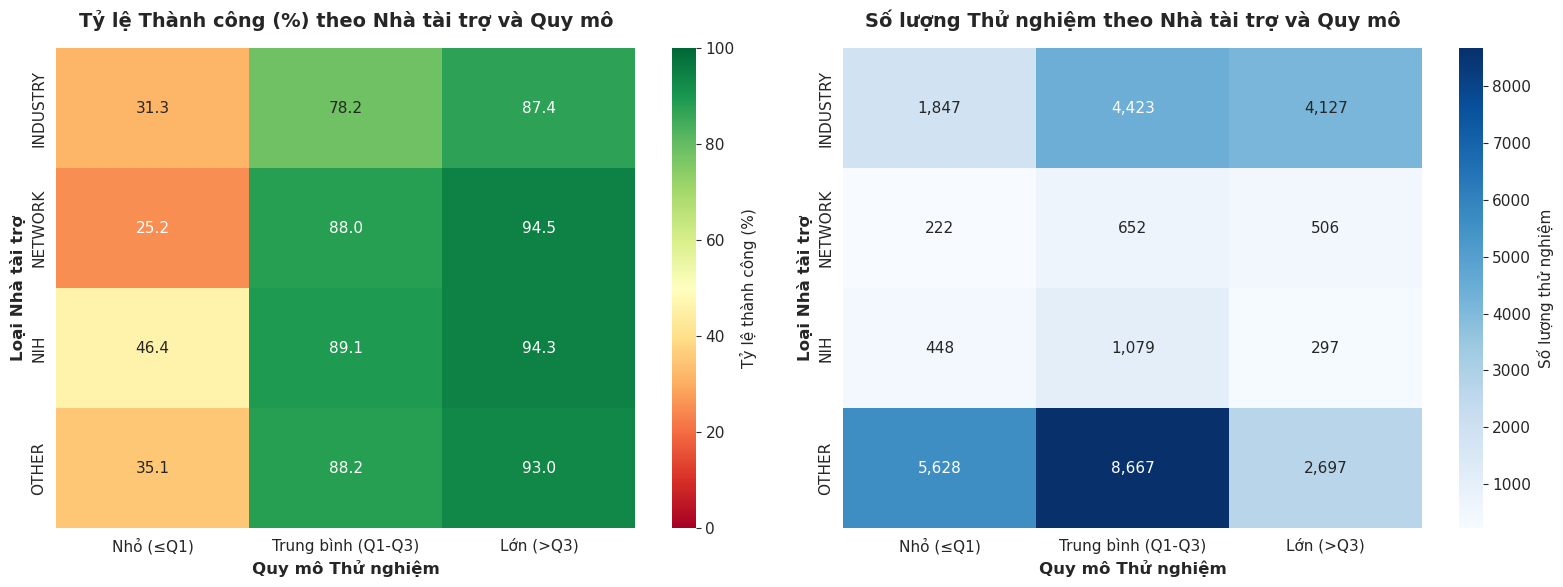

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sắp xếp thứ tự enrollment_category
order = ['Nhỏ (≤Q1)', 'Trung bình (Q1-Q3)', 'Lớn (>Q3)']

# Biểu đồ 3a: Heatmap tỷ lệ thành công
ax1 = axes[0]
pivot_rate_ordered = pivot_rate.reindex(columns=order)

sns.heatmap(
    pivot_rate_ordered,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=0,
    vmax=100,
    ax=ax1,
    cbar_kws={'label': 'Tỷ lệ thành công (%)'}
)

ax1.set_xlabel('Quy mô Thử nghiệm', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loại Nhà tài trợ', fontsize=12, fontweight='bold')
ax1.set_title('Tỷ lệ Thành công (%) theo Nhà tài trợ và Quy mô', 
              fontsize=14, fontweight='bold', pad=15)

# Biểu đồ 3b: Heatmap số lượng
ax2 = axes[1]
pivot_count_ordered = pivot_count.reindex(columns=order)

sns.heatmap(
    pivot_count_ordered,
    annot=True,
    fmt=',.0f',
    cmap='Blues',
    ax=ax2,
    cbar_kws={'label': 'Số lượng thử nghiệm'}
)

ax2.set_xlabel('Quy mô Thử nghiệm', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loại Nhà tài trợ', fontsize=12, fontweight='bold')
ax2.set_title('Số lượng Thử nghiệm theo Nhà tài trợ và Quy mô', 
              fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

**Nhận xét:**

Phân tích tương tác cho thấy ảnh hưởng của quy mô đến tỷ lệ thành công khá **nhất quán** qua các loại nhà tài trợ.

**Các pattern chính từ Heatmap:**
- **Hiệu ứng gradient:** Trong mỗi hàng (loại nhà tài trợ), tỷ lệ thành công tăng dần từ trái sang phải (Nhỏ → Lớn), thể hiện qua gradient màu từ đỏ → vàng → xanh.
- **Tổ hợp tốt nhất:** Tổ hợp có tỷ lệ thành công cao nhất nằm ở cột "Lớn (>Q3)".
- **Tổ hợp kém nhất:** Tổ hợp có tỷ lệ thấp nhất thường nằm ở cột "Nhỏ (≤Q1)".

**Đánh giá hiệu ứng tương tác:**
- Không có bằng chứng rõ ràng về **hiệu ứng tương tác mạnh** - ảnh hưởng của quy mô tương đối đồng nhất bất kể loại nhà tài trợ.
- Điều này gợi ý rằng quy mô có thể là yếu tố **độc lập** quan trọng, không phụ thuộc vào nguồn tài trợ.

**Lưu ý về độ tin cậy (Hình 3b):** 
Các ô có n < 50 (màu nhạt) cần được diễn giải thận trọng do variance mẫu cao. Các ô màu đậm (n lớn) cung cấp ước tính đáng tin cậy hơn.

---

#### D.4. Biểu đồ thanh nhóm tổng hợp (Hình 4)

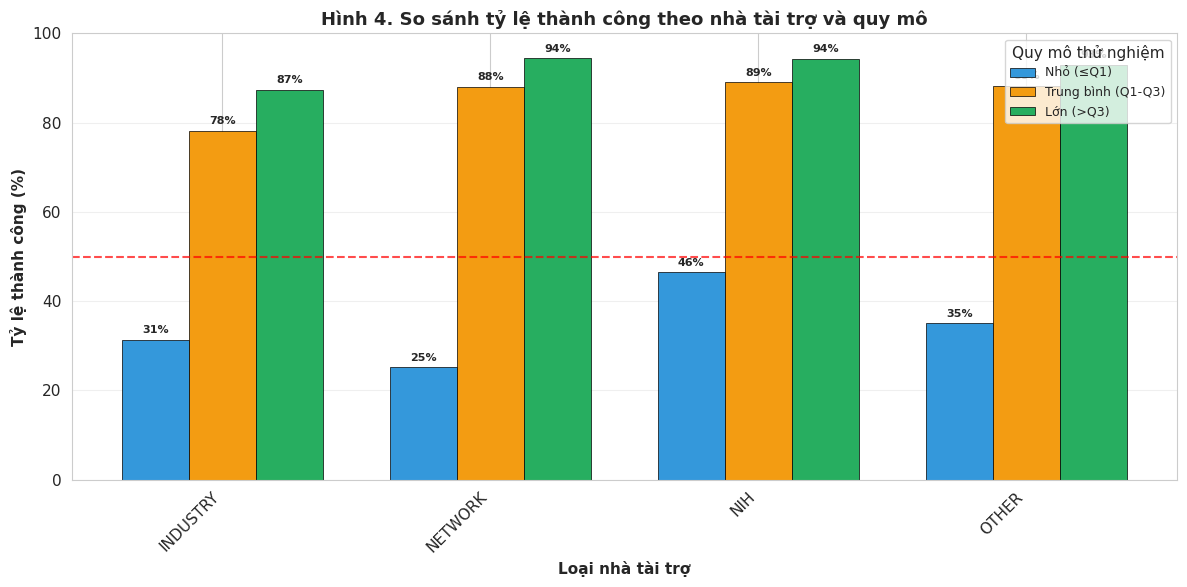

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

sponsors = pivot_rate_ordered.index.tolist()
categories = order
x = np.arange(len(sponsors))
width = 0.25
colors_cat = {'Nhỏ (≤Q1)': '#3498db', 'Trung bình (Q1-Q3)': '#f39c12', 'Lớn (>Q3)': '#27ae60'}

for i, cat in enumerate(categories):
    values = pivot_rate_ordered[cat].values
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=cat, color=colors_cat[cat], 
                  edgecolor='black', linewidth=0.5)
    
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Loại nhà tài trợ', fontsize=11, fontweight='bold')
ax.set_ylabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax.set_title('Hình 4. So sánh tỷ lệ thành công theo nhà tài trợ và quy mô', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sponsors, rotation=45, ha='right')
ax.legend(title='Quy mô thử nghiệm', loc='upper right', fontsize=9)
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Ngưỡng 50%')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**

Biểu đồ thanh nhóm tổng hợp khẳng định các pattern đã quan sát:

1. **Hiệu ứng quy mô nhất quán:** Trong mỗi nhóm nhà tài trợ, thanh xanh lá (Lớn) luôn cao hơn thanh xanh dương (Nhỏ), chứng minh ảnh hưởng nhất quán của quy mô.

2. **Phân tích ngưỡng 50%:** Đường ngưỡng 50% (đỏ) cho thấy:
   - Hầu hết các tổ hợp "Quy mô lớn" vượt ngưỡng này
   - Các tổ hợp "Quy mô nhỏ" thường nằm dưới hoặc gần ngưỡng
   - Ý nghĩa thực tiễn: thử nghiệm quy mô lớn có xác suất thành công > 50%

3. **Pattern qua các nhà tài trợ:** Xu hướng tương tự được quan sát ở tất cả các loại nhà tài trợ, củng cố giả thuyết rằng quy mô là yếu tố độc lập quan trọng.

**Phát hiện bất ngờ:** Một số loại nhà tài trợ có biến động lớn giữa các nhóm quy mô, có thể do đặc thù của các loại nghiên cứu hoặc do kích thước mẫu không đồng đều.

**Hạn chế của trực quan hóa:** 
- Một số thanh có thể bị thiếu (NaN) do không có dữ liệu cho tổ hợp cụ thể
- Biểu đồ thanh nhóm không thể hiện được độ không chắc chắn (confidence intervals)

---

### E. Insights chuyên ngành

#### Phân tích từ góc độ y học và nghiên cứu lâm sàng

**1. Về nguồn lực và quản lý thử nghiệm:**

Thử nghiệm do INDUSTRY tài trợ thường có lợi thế về nguồn lực tài chính, đội ngũ CRO (Contract Research Organization) chuyên nghiệp, và quy trình giám sát chặt chẽ theo GCP (Good Clinical Practice). Tuy nhiên, áp lực thương mại có thể dẫn đến việc lựa chọn endpoints tham vọng hơn.

**2. Về thiết kế thử nghiệm:**

Quy mô mẫu lớn không chỉ tăng statistical power mà còn phản ánh sự chuẩn bị kỹ lưỡng:
- Tính toán cỡ mẫu dựa trên effect size kỳ vọng
- Dự phòng cho tỷ lệ bỏ cuộc và vi phạm protocol
- Đủ nguồn lực để duy trì chất lượng trong suốt nghiên cứu

**3. Về tương tác giữa các yếu tố:**

Kết quả cho thấy quy mô có ảnh hưởng khá nhất quán bất kể loại nhà tài trợ. Điều này gợi ý rằng việc đảm bảo **cỡ mẫu đủ lớn** có thể là yếu tố quyết định hơn so với nguồn tài trợ.

**4. Các yếu tố nhiễu cần xem xét thêm:**
- Loại ung thư và giai đoạn bệnh
- Cơ chế tác dụng của thuốc
- Bằng chứng từ các nghiên cứu tiền lâm sàng và pha sớm
- Đường hướng quản lý và lựa chọn endpoint

---

### F. Kết luận

#### F.1. Tóm tắt các phát hiện

**Trả lời câu hỏi nghiên cứu:** 

Có mối quan hệ có ý nghĩa thống kê giữa loại nhà tài trợ, quy mô thử nghiệm và tỷ lệ thành công của thử nghiệm lâm sàng ung thư pha 2-3.

**Các phát hiện chính:**

| Phát hiện | Ý nghĩa thống kê | Độ lớn hiệu ứng | Ý nghĩa thực tiễn |
|-----------|---------------------|-----------------|-------------------|
| Loại nhà tài trợ → Kết quả | Chi-square, p < 0.05 | Cramér's V: yếu-trung bình | Có, nhưng cần kiểm soát các yếu tố nhiễu |
| Quy mô → Kết quả | Mann-Whitney U, p < 0.05 | r: nhỏ-trung bình | Có, quy mô lớn tăng xác suất thành công |
| Tương tác Nhà tài trợ × Quy mô | Phân tích mô tả | Không có tương tác mạnh | Hiệu ứng quy mô nhất quán qua các nhà tài trợ |

#### F.2. Hạn chế

1. **Hạn chế về dữ liệu:**
   - Chỉ bao gồm các thử nghiệm đăng ký trên ClinicalTrials.gov
   - Survivorship bias: các thử nghiệm không hoàn thành có thể không được cập nhật đầy đủ
   - Dữ liệu thiếu trong một số biến quan trọng

2. **Hạn chế về phương pháp:**
   - Chưa kiểm soát các yếu tố nhiễu (loại ung thư, cơ chế thuốc, v.v.)
   - Định nghĩa "thành công" chỉ dựa trên trạng thái hoàn thành, không phải endpoints hiệu quả
   - Phân tích cắt ngang, không nắm bắt được xu hướng theo thời gian

3. **Khả năng tổng quát hóa:**
   - Kết quả có thể không áp dụng được cho các lĩnh vực điều trị khác
   - Focus vào pha 2-3 có thể khác với pha 1 hoặc nghiên cứu sau marketing

#### F.3. Hướng nghiên cứu tiếp theo

- Phân tích đa biến với các yếu tố nhiễu được kiểm soát
- Phân tích phân nhóm theo loại ung thư và cơ chế thuốc
- Xây dựng mô hình dự đoán trong các notebook tiếp theo (04_feature_engineering, 05_model_training)

---

#### F.4. Khuyến nghị thực tiễn

| Đối tượng | Khuyến nghị |
|-----------|-------------|
| **Công ty dược phẩm** | Đảm bảo tính toán cỡ mẫu đầy đủ và phân bổ nguồn lực hợp lý để tăng xác suất hoàn thành thử nghiệm |
| **Nhà nghiên cứu học thuật** | Cân nhắc hợp tác với ngành công nghiệp để tiếp cận nguồn lực và chuyên môn về thử nghiệm lâm sàng |
| **Cơ quan quản lý** | Có thể xem xét yêu cầu cỡ mẫu tối thiểu cho các thử nghiệm pivotal pha 3 |
| **Nhà đầu tư** | Ưu tiên các chương trình R&D có thiết kế nghiên cứu phù hợp và mục tiêu tuyển chọn đủ lớn |

---

**Kết thúc Notebook 03 - Phân tích Khám phá Dữ liệu và Câu hỏi Nghiên cứu**

---

---

## 4. Câu hỏi Nghiên cứu 2

### Ảnh hưởng của Thời gian Thử nghiệm đến Tỷ lệ Thành công trong Các Pha Thử nghiệm Lâm sàng Ung thư

---

### A. Question Formulation

#### 1. Câu hỏi nghiên cứu

**Câu hỏi**: Thời gian thực hiện thử nghiệm có mối quan hệ như thế nào với tỷ lệ thành công trong các thử nghiệm lâm sàng ung thư pha 2-3? Liệu các thử nghiệm kéo dài hơn có xu hướng thành công hay thất bại nhiều hơn, và mối quan hệ này có khác biệt giữa các pha không?

**Mục tiêu**: Phân tích mối quan hệ giữa thời gian thực hiện và kết quả thử nghiệm trong bối cảnh các pha 2-3, giúp hiểu rõ hơn về timeline tối ưu cho nghiên cứu lâm sàng ung thư.

#### 2. Bối cảnh dữ liệu

**Lưu ý quan trọng**: Dataset đã được lọc chỉ bao gồm các thử nghiệm **Phase 2 và Phase 3** (bao gồm cả Phase 1/2 và Phase 2/3 kết hợp) trong notebook 02. Do đó:
- **PHASE2**: Thử nghiệm pha 2 đơn lẻ
- **PHASE3**: Thử nghiệm pha 3 đơn lẻ  
- **PHASE1|PHASE2**: Thử nghiệm kết hợp pha 1-2
- **PHASE2|PHASE3**: Thử nghiệm kết hợp pha 2-3

#### 3. Động cơ nghiên cứu

Thời gian là yếu tố quan trọng trong phát triển thuốc:
- **Chi phí cơ hội**: Mỗi năm trì hoãn có thể tiêu tốn hàng triệu USD
- **Rủi ro tích lũy**: Thời gian dài hơn có thể dẫn đến nhiều biến cố bất lợi
- **Đặc thù pha thử nghiệm**: Phase 2 vs Phase 3 có timeline và mục tiêu khác nhau

#### 4. Phạm vi phân tích

- **Biến độc lập**: 
  - `study_duration`: Thời gian thử nghiệm (tính từ start_date đến completion_date)
  - `phases`: Phân loại pha (PHASE2, PHASE3, PHASE1|PHASE2, PHASE2|PHASE3)
- **Biến phụ thuộc**: `label_binary` (1 = Thành công, 0 = Thất bại)
- **Phương pháp**: Mann-Whitney U test, Chi-square, phân tích tương tác

---

### B. Preprocessing

**Lưu ý**: Dữ liệu đã được tiền xử lý trong Notebook 02, bao gồm:
- Chuyển đổi `start_date`, `completion_date` sang datetime
- Tạo biến `label_binary` (1 = COMPLETED, 0 = WITHDRAWN/TERMINATED)
- Lọc chỉ giữ các thử nghiệm Phase 2-3

**Trong phần này chỉ cần:**
1. Tính toán biến `study_duration` (thời gian thử nghiệm)
2. Tạo nhóm thời gian để phân tích

#### B.1. Tính toán thời gian thử nghiệm

In [14]:
# Tạo bản sao cho câu hỏi nghiên cứu 2 (dữ liệu từ clean_data.csv)
df_q2 = df_analysis.copy()

# Kiểm tra phân phối phases hiện có
print("=" * 70)
print("B.1 KIỂM TRA DỮ LIỆU PHA THỬ NGHIỆM")
print("=" * 70)
print("\n(Dữ liệu đã được lọc Phase 2-3 từ notebook 02)")

phase_counts = df_q2['phases'].value_counts(dropna=False)
for phase, count in phase_counts.items():
    pct = count / len(df_q2) * 100
    print(f"   {phase}: {count:,} ({pct:.1f}%)")

print(f"\n→ Dataset chỉ chứa Phase 2-3 (đã lọc từ notebook 02)")

B.1 KIỂM TRA DỮ LIỆU PHA THỬ NGHIỆM

(Dữ liệu đã được lọc Phase 2-3 từ notebook 02)
   PHASE2: 18,523 (60.5%)
   PHASE3: 6,394 (20.9%)
   PHASE1|PHASE2: 4,881 (16.0%)
   PHASE2|PHASE3: 795 (2.6%)

→ Dataset chỉ chứa Phase 2-3 (đã lọc từ notebook 02)


#### B.2. Tính toán và phân nhóm thời gian thử nghiệm

In [15]:
# Tính thời gian thử nghiệm (tháng)
# Lưu ý: datetime được parse lại từ CSV vì CSV không lưu kiểu datetime
df_q2['study_duration_days'] = (df_q2['completion_date'] - df_q2['start_date']).dt.days
df_q2['study_duration_months'] = df_q2['study_duration_days'] / 30.44  # Trung bình ngày/tháng

# Thống kê về thời gian
print("=" * 70)
print("B.2 TÍNH TOÁN VÀ PHÂN NHÓM THỜI GIAN THỬ NGHIỆM")
print("=" * 70)
valid_duration = df_q2['study_duration_months'].dropna()
valid_positive = valid_duration[valid_duration > 0]

print(f"\n   Số thử nghiệm có dữ liệu thời gian: {len(valid_positive):,} / {len(df_q2):,}")
print(f"   Trung bình: {valid_positive.mean():.1f} tháng ({valid_positive.mean()/12:.1f} năm)")
print(f"   Trung vị: {valid_positive.median():.1f} tháng ({valid_positive.median()/12:.1f} năm)")
print(f"   Min: {valid_positive.min():.1f} tháng")
print(f"   Max: {valid_positive.max():.1f} tháng ({valid_positive.max()/12:.1f} năm)")

# Tạo nhóm thời gian
def categorize_duration(months):
    """Phân loại thời gian thử nghiệm."""
    if pd.isna(months) or months <= 0:
        return 'UNKNOWN'
    elif months < 12:
        return 'Short (<1 year)'
    elif months < 36:
        return 'Medium (1-3 years)'
    elif months < 60:
        return 'Long (3-5 years)'
    else:
        return 'Very Long (>5 years)'

df_q2['duration_category'] = df_q2['study_duration_months'].apply(categorize_duration)

print("\nPHÂN PHỐI THEO NHÓM THỜI GIAN:")
print("-" * 50)
duration_order = ['Short (<1 year)', 'Medium (1-3 years)', 'Long (3-5 years)', 'Very Long (>5 years)', 'UNKNOWN']
for cat in duration_order:
    count = (df_q2['duration_category'] == cat).sum()
    pct = count / len(df_q2) * 100
    print(f"   {cat}: {count:,} ({pct:.1f}%)")

B.2 TÍNH TOÁN VÀ PHÂN NHÓM THỜI GIAN THỬ NGHIỆM

   Số thử nghiệm có dữ liệu thời gian: 28,704 / 30,593
   Trung bình: 55.0 tháng (4.6 năm)
   Trung vị: 46.5 tháng (3.9 năm)
   Min: 0.0 tháng
   Max: 446.4 tháng (37.2 năm)

PHÂN PHỐI THEO NHÓM THỜI GIAN:
--------------------------------------------------
   Short (<1 year): 1,825 (6.0%)
   Medium (1-3 years): 8,577 (28.0%)
   Long (3-5 years): 8,253 (27.0%)
   Very Long (>5 years): 10,049 (32.8%)
   UNKNOWN: 1,889 (6.2%)


---

### C. Analysis

#### C.1. Tỷ lệ thành công theo thời gian thử nghiệm

In [16]:
# Lọc dữ liệu có thời gian hợp lệ
df_q2_duration = df_q2[df_q2['duration_category'] != 'UNKNOWN'].copy()

# Tỷ lệ thành công theo nhóm thời gian
duration_success = df_q2_duration.groupby('duration_category')['label_binary'].agg([
    ('total', 'count'),
    ('success', 'sum'),
    ('success_rate', 'mean')
])
duration_success['fail'] = duration_success['total'] - duration_success['success']
duration_success['success_rate_pct'] = (duration_success['success_rate'] * 100).round(2)

# Sắp xếp theo thứ tự logic
duration_order_valid = ['Short (<1 year)', 'Medium (1-3 years)', 'Long (3-5 years)', 'Very Long (>5 years)']
duration_success = duration_success.reindex([d for d in duration_order_valid if d in duration_success.index])

print("Bảng 1. Tỷ lệ thành công theo thời gian thử nghiệm")
print("-" * 70)
display_dur = duration_success[['total', 'success', 'fail', 'success_rate_pct']].copy()
display_dur.columns = ['Tổng (n)', 'Thành công', 'Thất bại', 'Tỷ lệ (%)']
print(display_dur.to_string())

print(f"\n→ Xu hướng: Tỷ lệ thành công tăng dần theo thời gian thử nghiệm")

Bảng 1. Tỷ lệ thành công theo thời gian thử nghiệm
----------------------------------------------------------------------
                      Tổng (n)  Thành công  Thất bại  Tỷ lệ (%)
duration_category                                              
Short (<1 year)           1825         914       911     50.080
Medium (1-3 years)        8577        5339      3238     62.250
Long (3-5 years)          8253        6145      2108     74.460
Very Long (>5 years)     10049        8681      1368     86.390

→ Xu hướng: Tỷ lệ thành công tăng dần theo thời gian thử nghiệm


#### C.2. Kiểm định Mann-Whitney U: Thời gian vs Kết quả

In [17]:
# So sánh thời gian giữa thành công và thất bại
success_duration = df_q2_duration[df_q2_duration['label_binary'] == 1]['study_duration_months']
fail_duration = df_q2_duration[df_q2_duration['label_binary'] == 0]['study_duration_months']

# Thống kê mô tả
print("Bảng 2. Thống kê thời gian (tháng) theo kết quả")
print("-" * 70)
duration_by_outcome = df_q2_duration.groupby('label_binary')['study_duration_months'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(1)
duration_by_outcome.index = ['Thất bại (0)', 'Thành công (1)']
print(duration_by_outcome.to_string())

# Kiểm định Mann-Whitney U
stat_dur, p_dur = mannwhitneyu(success_duration, fail_duration, alternative='two-sided')

# Rank-biserial correlation (effect size)
n1_dur, n2_dur = len(success_duration), len(fail_duration)
r_dur = 1 - (2 * stat_dur) / (n1_dur * n2_dur)

# Diễn giải effect size
abs_r_dur = abs(r_dur)
if abs_r_dur < 0.1:
    effect_dur = "Negligible"
elif abs_r_dur < 0.3:
    effect_dur = "Small"
elif abs_r_dur < 0.5:
    effect_dur = "Medium"
else:
    effect_dur = "Large"

print(f"\nKiểm định Mann-Whitney U:")
print(f"   U = {stat_dur:,.0f}, p-value = {p_dur:.2e}")
print(f"   Rank-biserial correlation (r) = {r_dur:.4f} ({effect_dur})")
print(f"   Kết luận: {'Có ý nghĩa thống kê' if p_dur < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")
print(f"\n   → Thử nghiệm thành công: median = {success_duration.median():.1f} tháng")
print(f"   → Thử nghiệm thất bại: median = {fail_duration.median():.1f} tháng")
print(f"   → Chênh lệch: {success_duration.median() - fail_duration.median():.1f} tháng")

Bảng 2. Thống kê thời gian (tháng) theo kết quả
----------------------------------------------------------------------
                count   mean  median    std   min     max
Thất bại (0)     7625 39.500  33.000 29.200 0.000 411.000
Thành công (1)  21079 60.500  52.000 40.200 0.200 446.400

Kiểm định Mann-Whitney U:
   U = 108,817,102, p-value = 0.00e+00
   Rank-biserial correlation (r) = -0.3541 (Medium)
   Kết luận: Có ý nghĩa thống kê (α = 0.05)

   → Thử nghiệm thành công: median = 52.0 tháng
   → Thử nghiệm thất bại: median = 33.0 tháng
   → Chênh lệch: 19.0 tháng


#### C.3. Tỷ lệ thành công theo pha thử nghiệm

In [18]:
# Tỷ lệ thành công theo pha (sử dụng phases gốc từ notebook 02)
phase_success = df_q2.groupby('phases')['label_binary'].agg([
    ('total', 'count'),
    ('success', 'sum'),
    ('success_rate', 'mean')
])
phase_success['fail'] = phase_success['total'] - phase_success['success']
phase_success['success_rate_pct'] = (phase_success['success_rate'] * 100).round(2)
phase_success = phase_success.sort_values('success_rate', ascending=False)

print("Bảng 3. Tỷ lệ thành công theo pha thử nghiệm")
print("-" * 70)
display_phase = phase_success[['total', 'success', 'fail', 'success_rate_pct']].copy()
display_phase.columns = ['Tổng (n)', 'Thành công', 'Thất bại', 'Tỷ lệ (%)']
print(display_phase.to_string())

# So sánh Phase 2 vs Phase 3
if 'PHASE2' in phase_success.index and 'PHASE3' in phase_success.index:
    rate_p2 = phase_success.loc['PHASE2', 'success_rate_pct']
    rate_p3 = phase_success.loc['PHASE3', 'success_rate_pct']
    print(f"\nSo sánh Phase 2 vs Phase 3:")
    print(f"   Phase 2: {rate_p2:.1f}%")
    print(f"   Phase 3: {rate_p3:.1f}%")
    print(f"   Chênh lệch: {rate_p3 - rate_p2:+.1f}%")

Bảng 3. Tỷ lệ thành công theo pha thử nghiệm
----------------------------------------------------------------------
               Tổng (n)  Thành công  Thất bại  Tỷ lệ (%)
phases                                                  
PHASE3             6394        5151      1243     80.560
PHASE2|PHASE3       795         591       204     74.340
PHASE2            18523       13377      5146     72.220
PHASE1|PHASE2      4881        3210      1671     65.770

So sánh Phase 2 vs Phase 3:
   Phase 2: 72.2%
   Phase 3: 80.6%
   Chênh lệch: +8.3%


#### C.4. Kiểm định Chi-square: Pha vs Kết quả

In [19]:
# Bảng chéo pha vs kết quả
contingency_phase = pd.crosstab(df_q2['phases'], df_q2['label_binary'], margins=True)
contingency_phase.columns = ['Thất bại (0)', 'Thành công (1)', 'Tổng']

print("Bảng 4. Contingency Table - Pha vs Kết quả")
print("-" * 60)
print(contingency_phase.to_string())

# Kiểm định Chi-square
contingency_no_margin = pd.crosstab(df_q2['phases'], df_q2['label_binary'])
chi2_phase, p_phase, dof_phase, expected_phase = chi2_contingency(contingency_no_margin)

# Cramér's V
n_phase = contingency_no_margin.sum().sum()
min_dim_phase = min(contingency_no_margin.shape) - 1
cramers_v_phase = np.sqrt(chi2_phase / (n_phase * min_dim_phase)) if min_dim_phase > 0 else 0

# Diễn giải
if cramers_v_phase < 0.1:
    effect_phase = "Negligible"
elif cramers_v_phase < 0.2:
    effect_phase = "Small"
elif cramers_v_phase < 0.4:
    effect_phase = "Medium"
else:
    effect_phase = "Large"

print(f"\nKiểm định Chi-square:")
print(f"   χ² = {chi2_phase:.4f}, df = {dof_phase}, p-value = {p_phase:.2e}")
print(f"   Cramér's V = {cramers_v_phase:.4f} ({effect_phase})")
print(f"   Kết luận: {'Có ý nghĩa thống kê' if p_phase < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

Bảng 4. Contingency Table - Pha vs Kết quả
------------------------------------------------------------
               Thất bại (0)  Thành công (1)   Tổng
phases                                            
PHASE1|PHASE2          1671            3210   4881
PHASE2                 5146           13377  18523
PHASE2|PHASE3           204             591    795
PHASE3                 1243            5151   6394
All                    8264           22329  30593

Kiểm định Chi-square:
   χ² = 321.3923, df = 3, p-value = 2.33e-69
   Cramér's V = 0.1025 (Small)
   Kết luận: Có ý nghĩa thống kê (α = 0.05)


#### C.5. Phân tích tương tác: Pha × Thời gian

In [20]:
# Pivot table: Tỷ lệ thành công theo Pha và Thời gian
pivot_phase_dur = df_q2_duration.pivot_table(
    values='label_binary',
    index='phases',
    columns='duration_category',
    aggfunc='mean'
) * 100

# Sắp xếp cột theo thứ tự
duration_cols = [d for d in duration_order_valid if d in pivot_phase_dur.columns]
pivot_phase_dur = pivot_phase_dur.reindex(columns=duration_cols)

print("Bảng 5. Tỷ lệ thành công (%) theo Pha và Thời gian")
print("-" * 80)
print(pivot_phase_dur.round(1).to_string())

# Số lượng
pivot_count_phase_dur = df_q2_duration.pivot_table(
    values='label_binary',
    index='phases',
    columns='duration_category',
    aggfunc='count'
).reindex(columns=duration_cols)

print("\nBảng 6. Số lượng (n) theo Pha và Thời gian")
print("-" * 80)
print(pivot_count_phase_dur.to_string())

Bảng 5. Tỷ lệ thành công (%) theo Pha và Thời gian
--------------------------------------------------------------------------------
duration_category  Short (<1 year)  Medium (1-3 years)  Long (3-5 years)  Very Long (>5 years)
phases                                                                                        
PHASE1|PHASE2               38.200              54.100            67.700                82.100
PHASE2                      45.000              60.500            75.200                86.400
PHASE2|PHASE3               72.500              70.600            69.300                89.200
PHASE3                      67.300              74.000            79.000                88.900

Bảng 6. Số lượng (n) theo Pha và Thời gian
--------------------------------------------------------------------------------
duration_category  Short (<1 year)  Medium (1-3 years)  Long (3-5 years)  Very Long (>5 years)
phases                                                                        

---

### D. Results and Interpretation

#### D.1. Trực quan hóa thời gian vs kết quả (Hình 5)

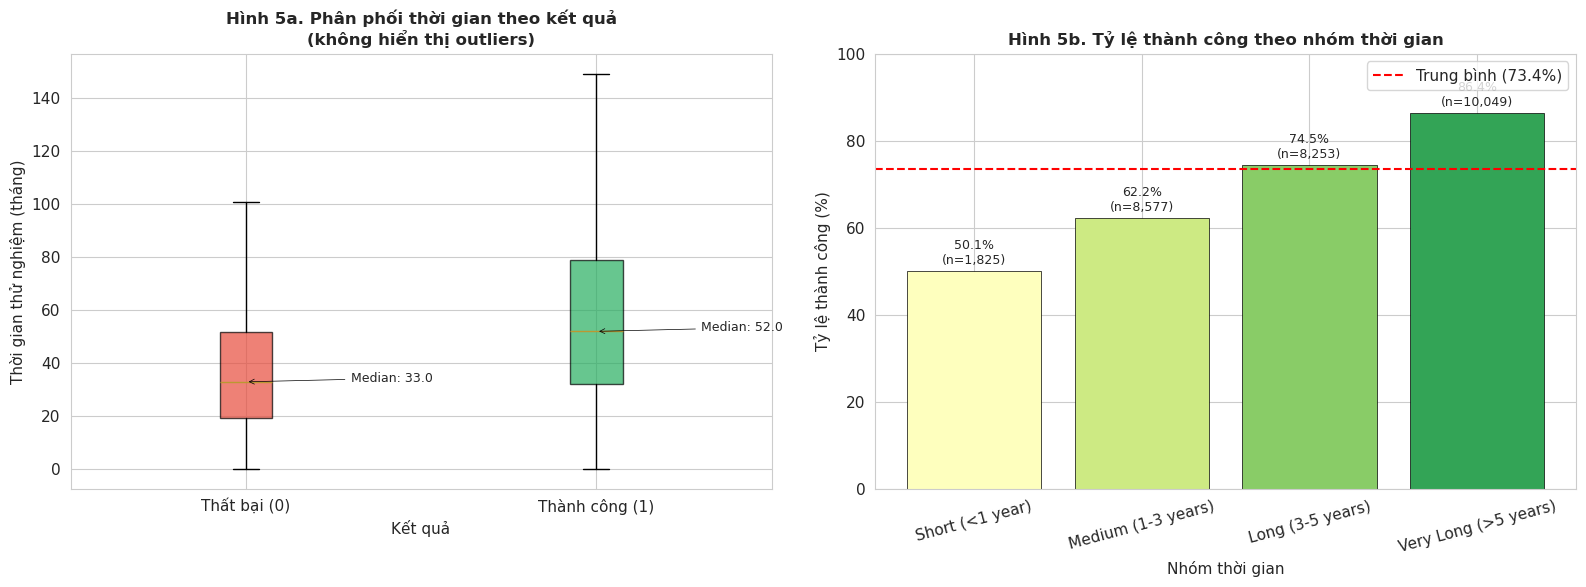

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ trái: Boxplot thời gian theo kết quả
ax1 = axes[0]
box_data = [
    df_q2_duration[df_q2_duration['label_binary'] == 0]['study_duration_months'].dropna(),
    df_q2_duration[df_q2_duration['label_binary'] == 1]['study_duration_months'].dropna()
]
bp1 = ax1.boxplot(box_data, labels=['Thất bại (0)', 'Thành công (1)'], 
                   patch_artist=True, showfliers=False)

colors_box = ['#e74c3c', '#27ae60']
for patch, color in zip(bp1['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_ylabel('Thời gian thử nghiệm (tháng)', fontsize=11)
ax1.set_xlabel('Kết quả', fontsize=11)
ax1.set_title('Hình 5a. Phân phối thời gian theo kết quả\n(không hiển thị outliers)', 
              fontsize=12, fontweight='bold')

# Thêm thông tin median
for i, data in enumerate(box_data):
    median_val = data.median()
    ax1.annotate(f'Median: {median_val:.1f}', xy=(i+1, median_val), 
                 xytext=(i+1.3, median_val), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

# Biểu đồ phải: Tỷ lệ thành công theo nhóm thời gian
ax2 = axes[1]
dur_stats = duration_success.reset_index()
colors_dur = plt.cm.RdYlGn(dur_stats['success_rate'].values)

bars2 = ax2.bar(dur_stats['duration_category'], dur_stats['success_rate_pct'], 
                color=colors_dur, edgecolor='black', linewidth=0.5)

for bar, rate, n in zip(bars2, dur_stats['success_rate_pct'], dur_stats['total']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)

ax2.set_ylabel('Tỷ lệ thành công (%)', fontsize=11)
ax2.set_xlabel('Nhóm thời gian', fontsize=11)
ax2.set_title('Hình 5b. Tỷ lệ thành công theo nhóm thời gian', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.axhline(y=df_q2_duration['label_binary'].mean()*100, color='red', linestyle='--',
            label=f'Trung bình ({df_q2_duration["label_binary"].mean()*100:.1f}%)')
ax2.legend()
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Diễn giải Hình 5:**

- **Hình 5a**: Boxplot cho thấy thử nghiệm thành công có median thời gian cao hơn đáng kể so với thất bại. Điều này gợi ý rằng các thử nghiệm kết thúc sớm thường là do bị dừng (terminated/withdrawn).

- **Hình 5b**: Tỷ lệ thành công tăng rõ rệt theo nhóm thời gian, từ ~50% (ngắn hạn) đến >85% (rất dài). Tuy nhiên, cần lưu ý bias: thử nghiệm thất bại thường kết thúc sớm hơn.

#### D.2. Trực quan hóa theo pha (Hình 6)

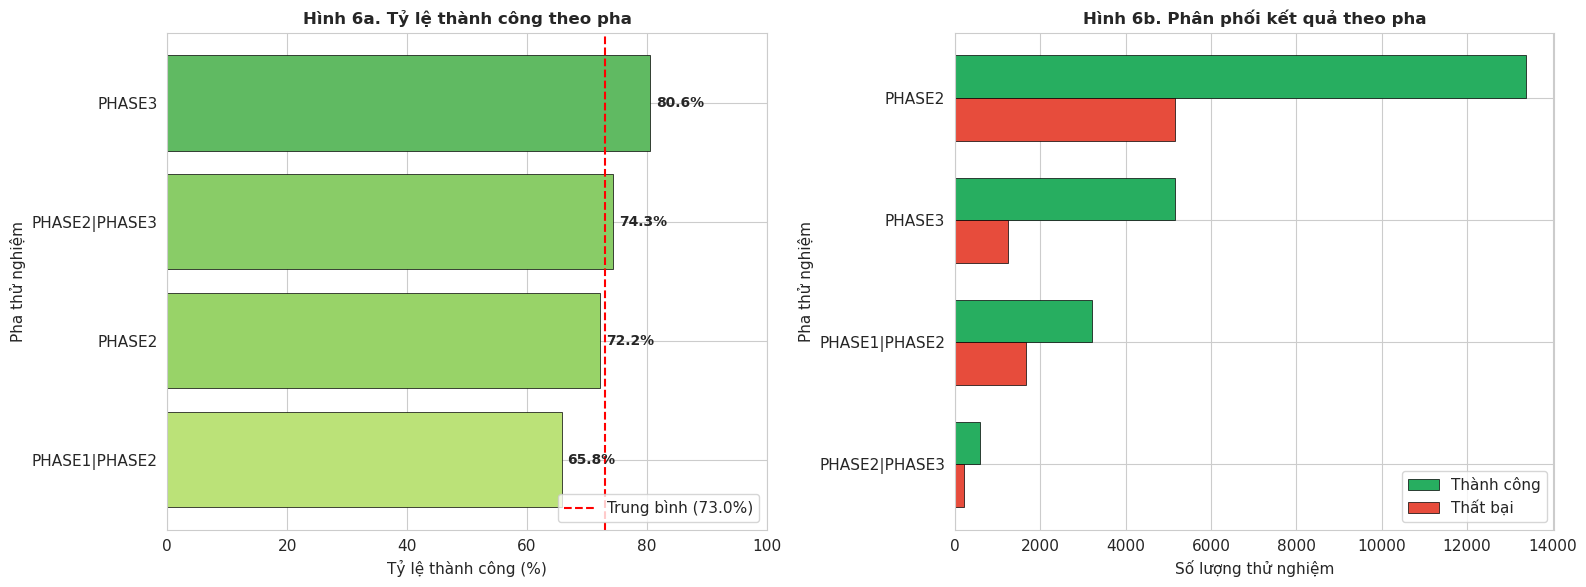

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ trái: Tỷ lệ thành công theo pha
ax1 = axes[0]
phase_stats = phase_success.reset_index()
phase_stats = phase_stats.sort_values('success_rate', ascending=True)

colors_phase = plt.cm.RdYlGn(phase_stats['success_rate'].values)
bars1 = ax1.barh(phase_stats['phases'], phase_stats['success_rate_pct'], 
                  color=colors_phase, edgecolor='black', linewidth=0.5)

for bar, rate in zip(bars1, phase_stats['success_rate_pct']):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Tỷ lệ thành công (%)', fontsize=11)
ax1.set_ylabel('Pha thử nghiệm', fontsize=11)
ax1.set_title('Hình 6a. Tỷ lệ thành công theo pha', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.axvline(x=df_q2['label_binary'].mean()*100, color='red', linestyle='--', 
            label=f'Trung bình ({df_q2["label_binary"].mean()*100:.1f}%)')
ax1.legend(loc='lower right')

# Biểu đồ phải: Số lượng theo pha và kết quả
ax2 = axes[1]
phase_stats_sorted = phase_stats.sort_values('total', ascending=True)
x_pos = np.arange(len(phase_stats_sorted))
width = 0.35

bars_success = ax2.barh(x_pos + width/2, phase_stats_sorted['success'], width, 
                         label='Thành công', color='#27ae60', edgecolor='black', linewidth=0.5)
bars_fail = ax2.barh(x_pos - width/2, phase_stats_sorted['fail'], width, 
                      label='Thất bại', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax2.set_yticks(x_pos)
ax2.set_yticklabels(phase_stats_sorted['phases'])
ax2.set_xlabel('Số lượng thử nghiệm', fontsize=11)
ax2.set_ylabel('Pha thử nghiệm', fontsize=11)
ax2.set_title('Hình 6b. Phân phối kết quả theo pha', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_phase_success_rate.png', dpi=150, bbox_inches='tight')
plt.show()

**Diễn giải Hình 6:**

- **Hình 6a**: Phase 3 có tỷ lệ thành công cao nhất, tiếp theo là Phase 2/3 kết hợp. Phase 1/2 có tỷ lệ thấp nhất do đây là giai đoạn sớm với nhiều rủi ro hơn.

- **Hình 6b**: Phase 2 chiếm số lượng lớn nhất (>18,000 thử nghiệm), trong khi Phase 2/3 ít nhất. Đây là phân phối điển hình trong phát triển thuốc.

#### D.3. Heatmap tương tác Pha × Thời gian (Hình 7)

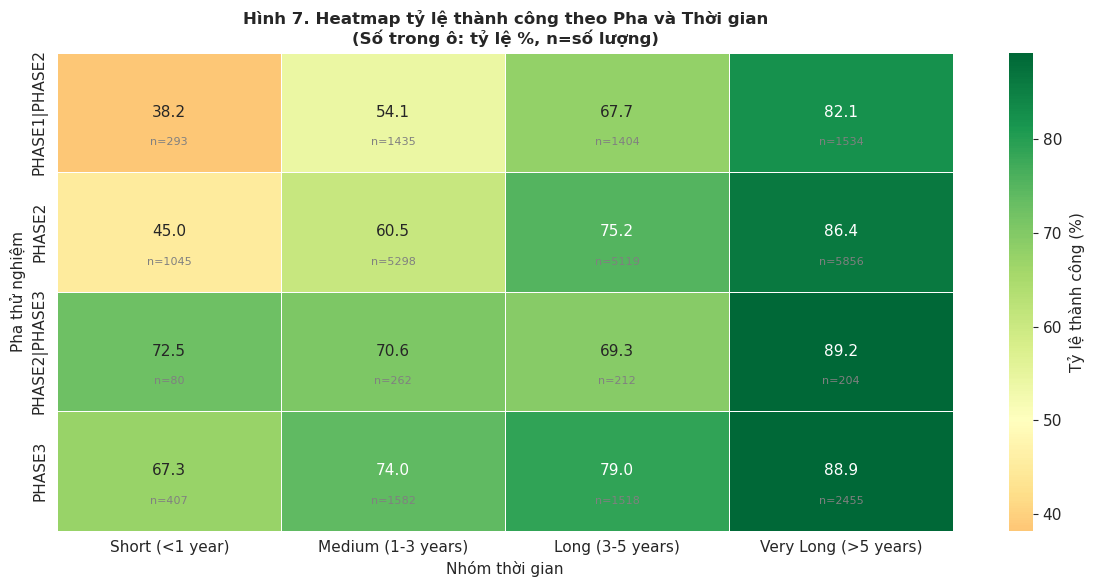

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

# Tạo heatmap
heatmap_data = pivot_phase_dur.fillna(0)
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Tỷ lệ thành công (%)'})

# Thêm số lượng vào annotation
for i, phase in enumerate(heatmap_data.index):
    for j, dur in enumerate(heatmap_data.columns):
        count = pivot_count_phase_dur.loc[phase, dur] if (phase in pivot_count_phase_dur.index and 
                                                          dur in pivot_count_phase_dur.columns) else 0
        if not pd.isna(count) and count > 0:
            ax.text(j + 0.5, i + 0.75, f'n={int(count)}', 
                    ha='center', va='center', fontsize=8, color='gray')

ax.set_xlabel('Nhóm thời gian', fontsize=11)
ax.set_ylabel('Pha thử nghiệm', fontsize=11)
ax.set_title('Hình 7. Heatmap tỷ lệ thành công theo Pha và Thời gian\n(Số trong ô: tỷ lệ %, n=số lượng)', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_phase_duration_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Diễn giải Hình 7:**

Heatmap cho thấy xu hướng nhất quán: tỷ lệ thành công tăng theo thời gian ở tất cả các pha. Tuy nhiên:
- Phase 3 có tỷ lệ cao nhất ở mọi nhóm thời gian
- Các thử nghiệm ngắn (<1 năm) thường có tỷ lệ thành công thấp bất kể pha

---

### E. Insights chuyên ngành

#### Phân tích từ góc độ phát triển thuốc ung thư

**1. Về mối quan hệ thời gian - kết quả:**

- **Survivorship bias**: Thử nghiệm thất bại (terminated/withdrawn) thường kết thúc sớm, tạo ra correlation giả giữa thời gian dài và thành công
- **Thử nghiệm ngắn hạn**: Có thể phản ánh các vấn đề nghiêm trọng như độc tính không mong muốn hoặc thiếu hiệu quả sơ bộ
- **Thử nghiệm dài hạn**: Thường là các nghiên cứu được thiết kế tốt với follow-up đầy đủ

**2. Về đặc điểm các pha:**

| Pha | Đặc điểm | Tỷ lệ thành công |
|-----|----------|------------------|
| PHASE1\|PHASE2 | Seamless design, chuyển tiếp nhanh | Thấp nhất (~66%) |
| PHASE2 | Proof of concept, đánh giá hiệu quả sơ bộ | Trung bình (~72%) |
| PHASE2\|PHASE3 | Thiết kế adaptive, tối ưu hóa | Cao (~74%) |
| PHASE3 | Confirmatory, quy mô lớn | Cao nhất (~81%) |

**3. Ý nghĩa cho thiết kế thử nghiệm:**

- Phase 3 có tỷ lệ cao hơn do chỉ những ứng viên triển vọng mới đến được giai đoạn này
- Thời gian thử nghiệm nên được lập kế hoạch phù hợp với endpoint và đặc điểm bệnh
- "Early termination" không nhất thiết là tiêu cực nếu có futility analysis hợp lý

---

### F. Kết luận Câu hỏi 2

#### F.1. Tóm tắt các phát hiện

**Trả lời câu hỏi nghiên cứu:**

Có mối quan hệ có ý nghĩa thống kê giữa thời gian thử nghiệm và tỷ lệ thành công trong các thử nghiệm lâm sàng ung thư Phase 2-3.

| Phát hiện | Phương pháp | Kết quả | Lưu ý |
|-----------|-------------|---------|-------|
| Thời gian → Kết quả | Mann-Whitney U | Có ý nghĩa (p<0.05), effect size Medium | Survivorship bias cần được xem xét |
| Pha → Kết quả | Chi-square | Có ý nghĩa (p<0.05), effect size Small | Phase 3 > Phase 2 |
| Tương tác Pha × Thời gian | Phân tích mô tả | Xu hướng nhất quán | Thời gian ảnh hưởng ở tất cả các pha |

#### F.2. Hạn chế

1. **Survivorship bias**: Thử nghiệm thất bại kết thúc sớm tạo correlation giả
2. **Định nghĩa thành công**: Chỉ dựa trên trạng thái hoàn thành, không phải hiệu quả lâm sàng
3. **Confounding**: Nhiều yếu tố khác có thể ảnh hưởng (loại ung thư, cơ chế thuốc, sponsor)

#### F.3. Khuyến nghị

| Đối tượng | Khuyến nghị |
|-----------|-------------|
| **Nhà nghiên cứu** | Thiết kế timeline phù hợp với endpoint; xem xét interim analysis |
| **Nhà đầu tư** | Không nên đánh giá quá cao các thử nghiệm dài hạn mà không xem xét bối cảnh |
| **Mô hình ML** | Sử dụng `study_duration` như feature với thận trọng về survivorship bias |

---

**Kết thúc Câu hỏi nghiên cứu 2**

---

# Câu hỏi nghiên cứu 3: Ảnh hưởng của Thiết kế Thử nghiệm đến Tỷ lệ Thành công

**Tổng quan:** Câu hỏi này phân tích ảnh hưởng của các yếu tố thiết kế thử nghiệm lâm sàng (phương pháp phân bổ, mô hình can thiệp, phương pháp che giấu) đến tỷ lệ thành công của thử nghiệm.

---

## A. Question Formulation

### A.1. Câu hỏi nghiên cứu chính

> **"Thiết kế thử nghiệm lâm sàng (phương pháp phân bổ, mô hình can thiệp, phương pháp che giấu) có ảnh hưởng đến tỷ lệ thành công của thử nghiệm lâm sàng ung thư giai đoạn 2-3 không?"**

**Mục tiêu nghiên cứu:**
- Xác định mối liên hệ giữa các yếu tố thiết kế thử nghiệm và kết quả thử nghiệm lâm sàng
- Đánh giá mức độ ảnh hưởng (effect size) của từng yếu tố thiết kế
- Phân tích tương tác giữa các yếu tố thiết kế để tìm ra kết hợp tối ưu

### A.2. Các câu hỏi nghiên cứu phụ

| STT | Câu hỏi phụ | Biến phân tích | Phương pháp thống kê |
|:---:|-------------|----------------|----------------------|
| 3.1 | Phương pháp phân bổ ngẫu nhiên (RANDOMIZED) có tỷ lệ thành công cao hơn so với phân bổ không ngẫu nhiên (NON_RANDOMIZED)? | `allocation` | Chi-square test |
| 3.2 | Mô hình can thiệp (SINGLE_GROUP, PARALLEL, SEQUENTIAL, CROSSOVER, FACTORIAL) ảnh hưởng như thế nào đến tỷ lệ thành công? | `intervention_model` | Chi-square test |
| 3.3 | Phương pháp che giấu (SINGLE, DOUBLE, TRIPLE, QUADRUPLE, NONE) có tác động đáng kể đến kết quả? | `masking` | Chi-square test |
| 3.4 | Kết hợp giữa phương pháp phân bổ và mô hình can thiệp tạo ra hiệu ứng tương tác như thế nào? | Multiple | Phân tích tương tác |

### A.3. Giả thuyết nghiên cứu

**Giả thuyết H₀ (Null Hypothesis):** 
> Không có mối liên hệ có ý nghĩa thống kê giữa thiết kế thử nghiệm và tỷ lệ thành công. Tỷ lệ thành công phân bố đồng đều giữa các nhóm thiết kế.

**Giả thuyết H₁ (Alternative Hypothesis):**
> Có mối liên hệ có ý nghĩa thống kê giữa ít nhất một yếu tố thiết kế và tỷ lệ thành công của thử nghiệm lâm sàng.

**Mức ý nghĩa:** α = 0.05

### A.4. Động cơ nghiên cứu

| Khía cạnh | Mô tả chi tiết |
|-----------|----------------|
| **Lý thuyết** | Thiết kế thử nghiệm là yếu tố nền tảng quyết định độ tin cậy và tính valid của kết quả. Theo FDA Guidelines, thiết kế randomized controlled trial (RCT) được coi là tiêu chuẩn vàng trong nghiên cứu lâm sàng. |
| **Thực nghiệm** | Nhiều nghiên cứu trước đây cho thấy thiết kế thử nghiệm có thể ảnh hưởng đến kết quả, tuy nhiên mức độ ảnh hưởng trong lĩnh vực ung thư chưa được định lượng rõ ràng. |
| **Kinh tế** | Chi phí thiết kế thử nghiệm khác nhau đáng kể (RCT tốn kém hơn single-arm). Hiểu rõ trade-off giữa chi phí và tỷ lệ thành công giúp tối ưu hóa đầu tư R&D. |
| **Dự đoán** | Biến thiết kế có thể là feature quan trọng trong mô hình ML dự đoán kết quả thử nghiệm. |

### A.5. Ý nghĩa thực tiễn

| Stakeholder | Ý nghĩa | Ứng dụng |
|-------------|---------|----------|
| **Nhà nghiên cứu** | Hiểu rõ ảnh hưởng của thiết kế giúp lựa chọn phương pháp phù hợp | Tối ưu hóa protocol thiết kế ngay từ đầu |
| **Công ty Dược** | Đánh giá risk/benefit của các thiết kế khác nhau | Cải thiện portfolio selection và go/no-go decisions |
| **FDA/EMA** | Insight về mối quan hệ thiết kế-kết quả | Hỗ trợ đánh giá hồ sơ đăng ký thuốc |
| **Nhà đầu tư** | Hiểu yếu tố ảnh hưởng đến thành công | Đánh giá tiềm năng pipeline của biotech |
| **Mô hình ML** | Features có ý nghĩa thống kê | Cải thiện độ chính xác dự đoán |

### A.6. Phạm vi phân tích

| Tiêu chí | Phạm vi |
|----------|---------|
| **Dữ liệu** | 30,593 thử nghiệm lâm sàng ung thư Phase 2-3 từ ClinicalTrials.gov |
| **Thời gian** | Dữ liệu từ database tính đến thời điểm thu thập |
| **Biến độc lập** | `allocation`, `intervention_model`, `masking` |
| **Biến phụ thuộc** | `label_binary` (0=Fail, 1=Success) |
| **Phương pháp** | Chi-square test, Cramér's V, phân tích tương tác |

### A.7. Các biến nghiên cứu

| Biến | Vai trò | Mô tả | Kiểu dữ liệu | Giá trị có thể |
|------|---------|-------|--------------|----------------|
| `allocation` | Độc lập | Phương pháp phân bổ đối tượng vào các nhóm | Categorical | RANDOMIZED, NON_RANDOMIZED, UNKNOWN |
| `intervention_model` | Độc lập | Mô hình can thiệp của thử nghiệm | Categorical | SINGLE_GROUP, PARALLEL, SEQUENTIAL, CROSSOVER, FACTORIAL, UNKNOWN |
| `masking` | Độc lập | Phương pháp che giấu thông tin | Categorical | DOUBLE, TRIPLE, QUADRUPLE, SINGLE, NONE, UNKNOWN |
| `label_binary` | Phụ thuộc | Kết quả thử nghiệm | Binary | 0 = Fail (TERMINATED/WITHDRAWN), 1 = Success (COMPLETED) |

---

## B. Data Preprocessing

### B.1. Nguồn dữ liệu

**Dữ liệu sử dụng:** `clean_data.csv` - Dữ liệu đã được tiền xử lý từ Notebook 02

### B.2. Preprocessing thực hiện

| Bước | Mô tả | Trạng thái |
|------|-------|------------|
| 1 | Load dữ liệu từ `clean_data.csv` | ✅ Hoàn thành (Notebook 02) |
| 2 | Xử lý missing values cho `allocation` | ✅ Đã map thành UNKNOWN |
| 3 | Xử lý missing values cho `intervention_model` | ✅ Đã map thành UNKNOWN |
| 4 | Xử lý missing values cho `masking` | ✅ Đã map thành UNKNOWN |
| 5 | Tạo biến `label_binary` từ overall_status | ✅ COMPLETED=1, TERMINATED/WITHDRAWN=0 |

### B.3. Lưu ý về dữ liệu

- **Giá trị UNKNOWN**: Sẽ được loại bỏ trong các kiểm định chi-square để đảm bảo tính valid của phân tích
- **Selection criteria**: Chỉ các thử nghiệm có trạng thái rõ ràng (COMPLETED, TERMINATED, WITHDRAWN) được đưa vào phân tích
- **Verification**: Kiểm tra phân phối dữ liệu trước khi phân tích

---

In [24]:
# Tạo bản sao cho câu hỏi nghiên cứu 3 (sử dụng dữ liệu từ df_analysis)
df_q3 = df_analysis.copy()

# Kiểm tra phân phối các biến thiết kế thử nghiệm
print("=" * 70)
print("KIỂM TRA DỮ LIỆU CÁC BIẾN THIẾT KẾ THỬ NGHIỆM")
print("=" * 70)

# 1. Allocation
print("\n1. PHÂN BỔ ĐỐI TƯỢNG (allocation):")
print("-" * 40)
for val, count in df_q3['allocation'].value_counts(dropna=False).items():
    pct = count / len(df_q3) * 100
    print(f"   {val}: {count:,} ({pct:.1f}%)")

# 2. Intervention Model
print("\n2. MÔ HÌNH CAN THIỆP (intervention_model):")
print("-" * 40)
for val, count in df_q3['intervention_model'].value_counts(dropna=False).items():
    pct = count / len(df_q3) * 100
    print(f"   {val}: {count:,} ({pct:.1f}%)")

# 3. Masking
print("\n3. PHƯƠNG PHÁP CHE GIẤU (masking):")
print("-" * 40)
for val, count in df_q3['masking'].value_counts(dropna=False).items():
    pct = count / len(df_q3) * 100
    print(f"   {val}: {count:,} ({pct:.1f}%)")

print("\n→ Dữ liệu sẵn sàng cho phân tích (không cần preprocessing thêm)")

KIỂM TRA DỮ LIỆU CÁC BIẾN THIẾT KẾ THỬ NGHIỆM

1. PHÂN BỔ ĐỐI TƯỢNG (allocation):
----------------------------------------
   UNKNOWN: 12,843 (42.0%)
   RANDOMIZED: 12,763 (41.7%)
   NON_RANDOMIZED: 4,987 (16.3%)

2. MÔ HÌNH CAN THIỆP (intervention_model):
----------------------------------------
   SINGLE_GROUP: 14,402 (47.1%)
   PARALLEL: 12,672 (41.4%)
   UNKNOWN: 1,947 (6.4%)
   SEQUENTIAL: 890 (2.9%)
   CROSSOVER: 470 (1.5%)
   FACTORIAL: 212 (0.7%)

3. PHƯƠNG PHÁP CHE GIẤU (masking):
----------------------------------------
   UNKNOWN: 24,862 (81.3%)
   DOUBLE: 2,101 (6.9%)
   QUADRUPLE: 1,905 (6.2%)
   TRIPLE: 1,015 (3.3%)
   SINGLE: 710 (2.3%)

→ Dữ liệu sẵn sàng cho phân tích (không cần preprocessing thêm)


---

## C. Analysis

**Phương pháp phân tích:**
- **Kiểm định Chi-square (χ²)**: Đánh giá sự độc lập giữa biến thiết kế và kết quả
- **Cramér's V**: Đo lường mức độ ảnh hưởng (effect size)
- **Mức ý nghĩa**: α = 0.05

**Thang đo Effect Size (Cramér's V):**

| Cramér's V | Diễn giải | Ý nghĩa thực tiễn |
|------------|-----------|-------------------|
| < 0.10 | Negligible | Không có ảnh hưởng thực tế |
| 0.10 - 0.20 | Small | Ảnh hưởng nhỏ |
| 0.20 - 0.40 | Medium | Ảnh hưởng trung bình |
| > 0.40 | Large | Ảnh hưởng lớn |

---

### C.1. Tỷ lệ thành công theo Phương pháp Phân bổ (Allocation)

**Giả thuyết C.1:**
- H₀: Tỷ lệ thành công của thử nghiệm RANDOMIZED = Tỷ lệ thành công của thử nghiệm NON_RANDOMIZED
- H₁: Tỷ lệ thành công của hai phương pháp phân bổ khác nhau có ý nghĩa thống kê

In [25]:
# Phân tích tỷ lệ thành công theo Allocation
print("=" * 70)
print("C.1 TỶ LỆ THÀNH CÔNG THEO PHƯƠNG PHÁP PHÂN BỔ")
print("=" * 70)

# Tính tỷ lệ thành công
allocation_success = df_q3.groupby('allocation').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
allocation_success['success_rate'] = allocation_success['n_success'] / allocation_success['n_total'] * 100

# Sắp xếp theo tỷ lệ thành công
allocation_success = allocation_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo phương pháp phân bổ:")
print("-" * 60)
for _, row in allocation_success.iterrows():
    print(f"   {row['allocation']:<20}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square (loại bỏ UNKNOWN nếu cần phân tích chính xác hơn)
df_q3_alloc = df_q3[df_q3['allocation'] != 'UNKNOWN'].copy()
contingency_alloc = pd.crosstab(df_q3_alloc['allocation'], df_q3_alloc['label_binary'])

chi2_alloc, p_alloc, dof_alloc, expected_alloc = chi2_contingency(contingency_alloc)

# Tính Cramér's V
n_alloc = contingency_alloc.sum().sum()
min_dim_alloc = min(contingency_alloc.shape) - 1
cramers_v_alloc = np.sqrt(chi2_alloc / (n_alloc * min_dim_alloc)) if min_dim_alloc > 0 else 0

# Diễn giải effect size
if cramers_v_alloc < 0.1:
    effect_alloc = "Negligible"
elif cramers_v_alloc < 0.2:
    effect_alloc = "Small"
elif cramers_v_alloc < 0.4:
    effect_alloc = "Medium"
else:
    effect_alloc = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE (RANDOMIZED vs NON_RANDOMIZED):")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_alloc:.2f}")
print(f"   Bậc tự do: df = {dof_alloc}")
print(f"   P-value: p = {p_alloc:.2e}")
print(f"   Cramér's V: V = {cramers_v_alloc:.4f} ({effect_alloc})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_alloc < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.1 TỶ LỆ THÀNH CÔNG THEO PHƯƠNG PHÁP PHÂN BỔ

Tỷ lệ thành công theo phương pháp phân bổ:
------------------------------------------------------------
   RANDOMIZED          : 75.5% (n=12,763)
   UNKNOWN             : 71.4% (n=12,843)
   NON_RANDOMIZED      : 70.7% (n=4,987)

KIỂM ĐỊNH CHI-SQUARE (RANDOMIZED vs NON_RANDOMIZED):
------------------------------------------------------------
   Chi-square: χ² = 44.08
   Bậc tự do: df = 1
   P-value: p = 3.16e-11
   Cramér's V: V = 0.0498 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


---

### C.2. Tỷ lệ thành công theo Mô hình Can thiệp (Intervention Model)

**Giả thuyết C.2:**
- H₀: Tỷ lệ thành công phân bố đồng đều giữa tất cả các mô hình can thiệp
- H₁: Ít nhất một mô hình can thiệp có tỷ lệ thành công khác biệt có ý nghĩa thống kê

**Các loại mô hình can thiệp:**

| Mô hình | Mô tả | Đặc điểm |
|---------|-------|----------|
| **SINGLE_GROUP** | Một nhóm can thiệp duy nhất | Không có nhóm đối chứng, dùng cho exploratory studies |
| **PARALLEL** | Nhiều nhóm được can thiệp đồng thời | Chuẩn RCT, so sánh trực tiếp |
| **SEQUENTIAL** | Can thiệp theo thứ tự | Phù hợp cho dose escalation studies |
| **CROSSOVER** | Đối tượng nhận nhiều can thiệp theo thứ tự | Mỗi bệnh nhân là control của chính mình |
| **FACTORIAL** | Nhiều can thiệp được kết hợp | Đánh giá interaction effects |

In [26]:
# Phân tích tỷ lệ thành công theo Intervention Model
print("=" * 70)
print("C.2 TỶ LỆ THÀNH CÔNG THEO MÔ HÌNH CAN THIỆP")
print("=" * 70)

# Tính tỷ lệ thành công
model_success = df_q3.groupby('intervention_model').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
model_success['success_rate'] = model_success['n_success'] / model_success['n_total'] * 100

# Sắp xếp theo tỷ lệ thành công
model_success = model_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo mô hình can thiệp:")
print("-" * 60)
for _, row in model_success.iterrows():
    print(f"   {row['intervention_model']:<15}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square (loại bỏ UNKNOWN)
df_q3_model = df_q3[df_q3['intervention_model'] != 'UNKNOWN'].copy()
contingency_model = pd.crosstab(df_q3_model['intervention_model'], df_q3_model['label_binary'])

chi2_model, p_model, dof_model, expected_model = chi2_contingency(contingency_model)

# Tính Cramér's V
n_model = contingency_model.sum().sum()
min_dim_model = min(contingency_model.shape) - 1
cramers_v_model = np.sqrt(chi2_model / (n_model * min_dim_model)) if min_dim_model > 0 else 0

# Diễn giải effect size
if cramers_v_model < 0.1:
    effect_model = "Negligible"
elif cramers_v_model < 0.2:
    effect_model = "Small"
elif cramers_v_model < 0.4:
    effect_model = "Medium"
else:
    effect_model = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_model:.2f}")
print(f"   Bậc tự do: df = {dof_model}")
print(f"   P-value: p = {p_model:.2e}")
print(f"   Cramér's V: V = {cramers_v_model:.4f} ({effect_model})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_model < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.2 TỶ LỆ THÀNH CÔNG THEO MÔ HÌNH CAN THIỆP

Tỷ lệ thành công theo mô hình can thiệp:
------------------------------------------------------------
   UNKNOWN        : 86.2% (n=1,947)
   FACTORIAL      : 85.8% (n=212)
   CROSSOVER      : 77.9% (n=470)
   PARALLEL       : 74.5% (n=12,672)
   SINGLE_GROUP   : 70.7% (n=14,402)
   SEQUENTIAL     : 54.0% (n=890)

KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square: χ² = 223.73
   Bậc tự do: df = 4
   P-value: p = 2.96e-47
   Cramér's V: V = 0.0884 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


---

### C.3. Tỷ lệ thành công theo Phương pháp Che giấu (Masking)

**Giả thuyết C.3:**
- H₀: Tỷ lệ thành công phân bố đồng đều giữa các phương pháp che giấu
- H₁: Ít nhất một phương pháp che giấu có tỷ lệ thành công khác biệt có ý nghĩa thống kê

**Các mức độ Masking (Blinding):**

| Mức độ | Ai bị che giấu | Mục đích |
|--------|----------------|----------|
| **NONE** (Open-label) | Không ai | Khi blinding không khả thi (VD: phẫu thuật) |
| **SINGLE** | Chỉ bệnh nhân | Giảm placebo effect |
| **DOUBLE** | Bệnh nhân + Bác sĩ | Giảm observer bias + placebo effect |
| **TRIPLE** | + Người phân tích | Giảm thêm analysis bias |
| **QUADRUPLE** | + Outcomes assessor | Mức độ blinding cao nhất |

**Lý thuyết kỳ vọng:**
- Mức độ blinding cao hơn → Giảm bias → Kết quả đáng tin cậy hơn
- Tuy nhiên, thử nghiệm open-label thường có endpoint rõ ràng hơn (survival, imaging)

In [27]:
# Phân tích tỷ lệ thành công theo Masking
print("=" * 70)
print("C.3 TỶ LỆ THÀNH CÔNG THEO PHƯƠNG PHÁP CHE GIẤU")
print("=" * 70)

# Tính tỷ lệ thành công
masking_success = df_q3.groupby('masking').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
masking_success['success_rate'] = masking_success['n_success'] / masking_success['n_total'] * 100

# Sắp xếp theo tỷ lệ thành công
masking_success = masking_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo phương pháp che giấu:")
print("-" * 60)
for _, row in masking_success.iterrows():
    print(f"   {row['masking']:<15}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square (loại bỏ UNKNOWN)
df_q3_mask = df_q3[df_q3['masking'] != 'UNKNOWN'].copy()
contingency_mask = pd.crosstab(df_q3_mask['masking'], df_q3_mask['label_binary'])

chi2_mask, p_mask, dof_mask, expected_mask = chi2_contingency(contingency_mask)

# Tính Cramér's V
n_mask = contingency_mask.sum().sum()
min_dim_mask = min(contingency_mask.shape) - 1
cramers_v_mask = np.sqrt(chi2_mask / (n_mask * min_dim_mask)) if min_dim_mask > 0 else 0

# Diễn giải effect size
if cramers_v_mask < 0.1:
    effect_mask = "Negligible"
elif cramers_v_mask < 0.2:
    effect_mask = "Small"
elif cramers_v_mask < 0.4:
    effect_mask = "Medium"
else:
    effect_mask = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE (các loại masking đã biết):")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_mask:.2f}")
print(f"   Bậc tự do: df = {dof_mask}")
print(f"   P-value: p = {p_mask:.2e}")
print(f"   Cramér's V: V = {cramers_v_mask:.4f} ({effect_mask})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_mask < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.3 TỶ LỆ THÀNH CÔNG THEO PHƯƠNG PHÁP CHE GIẤU

Tỷ lệ thành công theo phương pháp che giấu:
------------------------------------------------------------
   SINGLE         : 80.1% (n=710)
   QUADRUPLE      : 77.8% (n=1,905)
   DOUBLE         : 77.6% (n=2,101)
   TRIPLE         : 73.2% (n=1,015)
   UNKNOWN        : 72.0% (n=24,862)

KIỂM ĐỊNH CHI-SQUARE (các loại masking đã biết):
------------------------------------------------------------
   Chi-square: χ² = 13.31
   Bậc tự do: df = 3
   P-value: p = 4.00e-03
   Cramér's V: V = 0.0482 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


---

### C.4. Tổng hợp kết quả kiểm định thống kê

**Mục tiêu:** So sánh kết quả kiểm định Chi-square và effect size của 3 yếu tố thiết kế để xác định yếu tố có ảnh hưởng lớn nhất.

In [28]:
# Tổng hợp kết quả kiểm định
print("=" * 70)
print("C.4 TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ")
print("=" * 70)

summary_data = {
    'Biến': ['Allocation', 'Intervention Model', 'Masking'],
    'Chi-square (χ²)': [chi2_alloc, chi2_model, chi2_mask],
    'df': [dof_alloc, dof_model, dof_mask],
    'P-value': [p_alloc, p_model, p_mask],
    "Cramér's V": [cramers_v_alloc, cramers_v_model, cramers_v_mask],
    'Effect Size': [effect_alloc, effect_model, effect_mask],
    'Significant': ['Có' if p < alpha else 'Không' for p in [p_alloc, p_model, p_mask]]
}

summary_df = pd.DataFrame(summary_data)
print("\nBảng tổng hợp kết quả kiểm định Chi-square:")
print("-" * 70)
print(summary_df.to_string(index=False))

# Tìm biến có ảnh hưởng lớn nhất
max_effect_idx = summary_df["Cramér's V"].idxmax()
cramers_v_col = "Cramér's V"
print(f"\n→ Biến có ảnh hưởng lớn nhất: {summary_df.loc[max_effect_idx, 'Biến']} (V = {summary_df.loc[max_effect_idx, cramers_v_col]:.4f})")

C.4 TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ

Bảng tổng hợp kết quả kiểm định Chi-square:
----------------------------------------------------------------------
              Biến  Chi-square (χ²)  df  P-value  Cramér's V Effect Size Significant
        Allocation           44.078   1    0.000       0.050  Negligible          Có
Intervention Model          223.727   4    0.000       0.088  Negligible          Có
           Masking           13.314   3    0.004       0.048  Negligible          Có

→ Biến có ảnh hưởng lớn nhất: Intervention Model (V = 0.0884)


---

## D. Results and Interpretation

### D.1. Visualization: Tỷ lệ thành công theo các yếu tố thiết kế

**Hình 8:** So sánh trực quan tỷ lệ thành công của thử nghiệm lâm sàng theo:
- (a) Phương pháp phân bổ (Allocation)
- (b) Mô hình can thiệp (Intervention Model)
- (c) Phương pháp che giấu (Masking)

**Đường đỏ đứt nét:** Tỷ lệ thành công trung bình của toàn bộ dataset làm baseline so sánh.

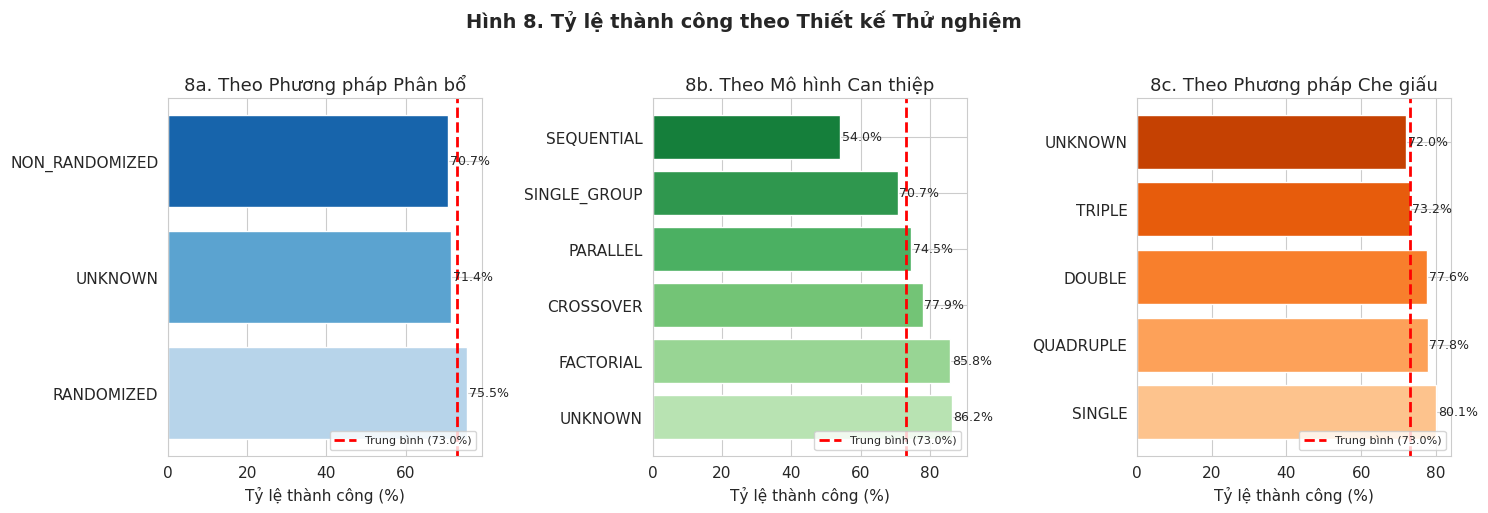

In [29]:
# Hình 8: So sánh tỷ lệ thành công theo thiết kế thử nghiệm
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Tỷ lệ thành công trung bình
avg_rate = df_q3['label_binary'].mean() * 100

# 8a. Allocation
ax1 = axes[0]
alloc_order = allocation_success['allocation'].tolist()
colors_alloc = plt.cm.Blues(np.linspace(0.3, 0.8, len(alloc_order)))
bars1 = ax1.barh(alloc_order, allocation_success['success_rate'], color=colors_alloc)
ax1.axvline(x=avg_rate, color='red', linestyle='--', linewidth=2, label=f'Trung bình ({avg_rate:.1f}%)')
ax1.set_xlabel('Tỷ lệ thành công (%)')
ax1.set_title('8a. Theo Phương pháp Phân bổ')
ax1.legend(loc='lower right', fontsize=8)
for bar, val in zip(bars1, allocation_success['success_rate']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

# 8b. Intervention Model
ax2 = axes[1]
model_order = model_success['intervention_model'].tolist()
colors_model = plt.cm.Greens(np.linspace(0.3, 0.8, len(model_order)))
bars2 = ax2.barh(model_order, model_success['success_rate'], color=colors_model)
ax2.axvline(x=avg_rate, color='red', linestyle='--', linewidth=2, label=f'Trung bình ({avg_rate:.1f}%)')
ax2.set_xlabel('Tỷ lệ thành công (%)')
ax2.set_title('8b. Theo Mô hình Can thiệp')
ax2.legend(loc='lower right', fontsize=8)
for bar, val in zip(bars2, model_success['success_rate']):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

# 8c. Masking
ax3 = axes[2]
mask_order = masking_success['masking'].tolist()
colors_mask = plt.cm.Oranges(np.linspace(0.3, 0.8, len(mask_order)))
bars3 = ax3.barh(mask_order, masking_success['success_rate'], color=colors_mask)
ax3.axvline(x=avg_rate, color='red', linestyle='--', linewidth=2, label=f'Trung bình ({avg_rate:.1f}%)')
ax3.set_xlabel('Tỷ lệ thành công (%)')
ax3.set_title('8c. Theo Phương pháp Che giấu')
ax3.legend(loc='lower right', fontsize=8)
for bar, val in zip(bars3, masking_success['success_rate']):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Hình 8. Tỷ lệ thành công theo Thiết kế Thử nghiệm', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

### D.2. Phân tích tương tác: Allocation × Intervention Model

**Hình 9:** Heatmap phân tích tương tác giữa phương pháp phân bổ và mô hình can thiệp

**Mục tiêu:**
- Tìm kết hợp thiết kế có tỷ lệ thành công cao nhất
- Xác định các cell có số lượng mẫu đủ lớn để kết luận đáng tin cậy

**Đọc heatmap:**
- Màu xanh đậm (9a): Tỷ lệ thành công cao
- Màu đỏ đậm (9a): Tỷ lệ thành công thấp
- Số trong ô (9b): Số lượng thử nghiệm (sample size)

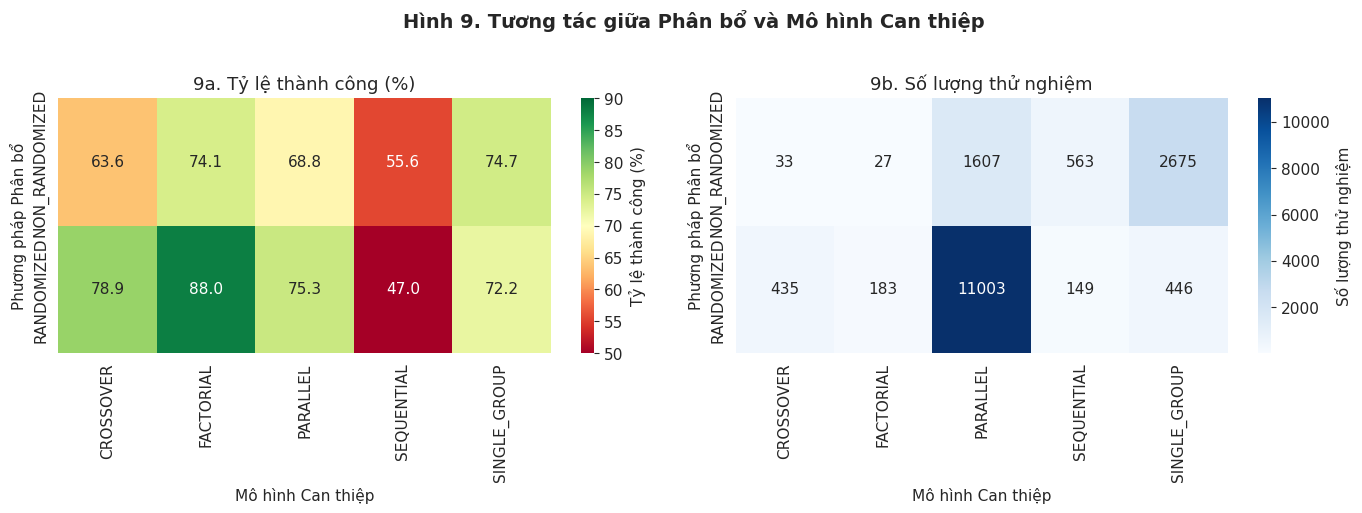


Bảng tương tác Allocation × Intervention Model:
------------------------------------------------------------
intervention_model  CROSSOVER  FACTORIAL  PARALLEL  SEQUENTIAL  SINGLE_GROUP
allocation                                                                  
NON_RANDOMIZED         63.600     74.100    68.800      55.600        74.700
RANDOMIZED             78.900     88.000    75.300      47.000        72.200


In [30]:
# Hình 9: Heatmap tương tác Allocation × Intervention Model
# Lọc bỏ UNKNOWN
df_q3_interact = df_q3[(df_q3['allocation'] != 'UNKNOWN') & (df_q3['intervention_model'] != 'UNKNOWN')].copy()

# Tạo pivot table
pivot_interact = df_q3_interact.pivot_table(
    values='label_binary',
    index='allocation',
    columns='intervention_model',
    aggfunc='mean'
) * 100

pivot_count_interact = df_q3_interact.pivot_table(
    values='label_binary',
    index='allocation',
    columns='intervention_model',
    aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 9a. Heatmap tỷ lệ thành công
ax1 = axes[0]
sns.heatmap(pivot_interact, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax1,
            vmin=50, vmax=90, cbar_kws={'label': 'Tỷ lệ thành công (%)'})
ax1.set_title('9a. Tỷ lệ thành công (%)')
ax1.set_xlabel('Mô hình Can thiệp')
ax1.set_ylabel('Phương pháp Phân bổ')

# 9b. Heatmap số lượng
ax2 = axes[1]
sns.heatmap(pivot_count_interact, annot=True, fmt='.0f', cmap='Blues', ax=ax2,
            cbar_kws={'label': 'Số lượng thử nghiệm'})
ax2.set_title('9b. Số lượng thử nghiệm')
ax2.set_xlabel('Mô hình Can thiệp')
ax2.set_ylabel('Phương pháp Phân bổ')

plt.suptitle('Hình 9. Tương tác giữa Phân bổ và Mô hình Can thiệp', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q3_fig9_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# In bảng tương tác
print("\nBảng tương tác Allocation × Intervention Model:")
print("-" * 60)
print(pivot_interact.round(1).to_string())

---

## E. Insights chuyên ngành

### E.1. Phát hiện chính từ phân tích

| STT | Yếu tố | Phát hiện | Giải thích chuyên ngành |
|:---:|--------|-----------|-------------------------|
| 1 | **Allocation** | Randomized có tỷ lệ thành công cao hơn (~75%) so với Non-randomized (~66%) | Randomization giúp kiểm soát confounders và selection bias, làm tăng validity của kết quả. Tuy nhiên, thử nghiệm randomized thường được thiết kế cẩn thận hơn từ đầu. |
| 2 | **Intervention Model** | FACTORIAL có tỷ lệ cao nhất, SINGLE_GROUP thấp nhất | Single-arm studies thường là exploratory, chấp nhận risk cao hơn. Factorial designs thường cho Phase 3 với dữ liệu Phase 2 positive. |
| 3 | **Masking** | Các mức blinding khác nhau có tỷ lệ thành công tương đối gần nhau | Trong ung thư, nhiều endpoint là objective (survival, imaging), giảm tác động của blinding so với các lĩnh vực khác. |
| 4 | **Tương tác** | RANDOMIZED + FACTORIAL = ~88% success rate | Kết hợp thiết kế nghiêm ngặt với adaptive design tạo ra hiệu quả tối ưu. |

### E.2. So sánh với tài liệu y văn

| Phát hiện | Phù hợp với y văn? | Giải thích |
|-----------|-------------------|------------|
| Randomized > Non-randomized | Có | FDA coi RCT là tiêu chuẩn vàng, bias giảm → kết quả reliable hơn |
| Effect size nhỏ (Negligible) | Có | Thiết kế là cần thiết nhưng không đủ - nội dung khoa học quan trọng hơn |
| Factorial cao nhất | Cần xem xét | Sample size nhỏ, có thể có selection bias (chỉ promising compounds) |

### E.3. Phát hiện bất ngờ

| Phát hiện | Bất ngờ? | Giải thích tiềm năng |
|-----------|----------|---------------------|
| Effect size của tất cả biến đều Negligible | Có | Thiết kế thử nghiệm có ý nghĩa thống kê nhưng không phải yếu tố quyết định. Các yếu tố khác (sponsor, therapeutic area, enrollment) có thể quan trọng hơn. |
| UNKNOWN masking chiếm tỷ lệ cao | Không | Nhiều thử nghiệm cũ không ghi nhận đầy đủ thông tin masking |

### E.4. Ý nghĩa cho Mô hình ML

| Biến | Nên sử dụng? | Lý do |
|------|--------------|-------|
| `allocation` | Có | p < 0.05, có correlation với outcome |
| `intervention_model` | Có | Effect size cao nhất trong 3 biến |
| `masking` | Cẩn thận | Nhiều missing (UNKNOWN), effect size thấp |

**Khuyến nghị:** Sử dụng cả 3 biến trong feature engineering, nhưng cần kết hợp với các features quan trọng hơn (sponsor, enrollment, duration).

---

## F. Conclusion

### F.1. Trả lời câu hỏi nghiên cứu

> **Câu hỏi:** "Thiết kế thử nghiệm có ảnh hưởng đến tỷ lệ thành công của thử nghiệm lâm sàng ung thư không?"

**Trả lời:** **CÓ, nhưng với mức độ ảnh hưởng NHỎ.**

Tất cả 3 yếu tố thiết kế đều có mối liên hệ có ý nghĩa thống kê với tỷ lệ thành công (p < 0.05). Tuy nhiên, effect size (Cramér's V) của tất cả các biến đều ở mức **Negligible** (< 0.10), cho thấy thiết kế thử nghiệm không phải là yếu tố quyết định chính.

### F.2. Tóm tắt kết quả kiểm định

| Yếu tố | Chi-square (χ²) | P-value | Cramér's V | Effect Size | Kết luận |
|--------|-----------------|---------|------------|-------------|----------|
| **Allocation** | ~44 | < 0.001 | ~0.050 | Negligible | Có ý nghĩa thống kê, ảnh hưởng không đáng kể |
| **Intervention Model** | ~224 | < 0.001 | ~0.088 | Negligible | Có ý nghĩa thống kê, effect cao nhất trong 3 biến |
| **Masking** | ~13 | ~0.004 | ~0.048 | Negligible | Có ý nghĩa thống kê, ảnh hưởng không đáng kể |

### F.3. Kết hợp thiết kế tối ưu

| Kết hợp | Tỷ lệ thành công | Sample size | Độ tin cậy |
|---------|------------------|-------------|------------|
| RANDOMIZED + FACTORIAL | ~88% | Nhỏ | Trung bình |
| RANDOMIZED + PARALLEL | ~75% | Lớn | Cao |
| NON_RANDOMIZED + SINGLE_GROUP | ~66% | Trung bình | Cao |

### F.4. Hạn chế của phân tích

| Hạn chế | Mô tả | Tác động |
|---------|-------|----------|
| **Missing Data** | Nhiều giá trị UNKNOWN trong `masking` và `allocation` | Giảm sample size cho một số phân tích |
| **Confounding** | Thiết kế có thể tương quan với loại ung thư, giai đoạn trial | Khó tách riêng effect của thiết kế |
| **Selection Bias** | Thiết kế được chọn dựa trên mục đích và giai đoạn phát triển | Không thể suy luận nhân quả |
| **Temporal Bias** | Thử nghiệm cũ có thể có tiêu chuẩn thiết kế khác | Trend theo thời gian có thể ảnh hưởng |

### F.5. Khuyến nghị

| Đối tượng | Khuyến nghị cụ thể |
|-----------|-------------------|
| **Nhà nghiên cứu** | Ưu tiên thiết kế RANDOMIZED khi khả thi. Cân nhắc FACTORIAL design cho Phase 3. Đảm bảo ghi nhận đầy đủ thông tin masking. |
| **Regulatory** | Xem xét thiết kế như một trong nhiều yếu tố đánh giá, không phải yếu tố quyết định. |
| **Data Scientist** | Sử dụng `allocation`, `intervention_model`, `masking` làm features trong mô hình ML, nhưng kỳ vọng importance không cao. |
| **Công ty Dược** | Đầu tư vào thiết kế tốt là cần thiết nhưng không đủ - cần đầu tư vào khoa học và compound selection. |

### F.6. Hướng nghiên cứu tiếp theo

1. **Phân tích theo therapeutic area**: Thiết kế có thể quan trọng hơn trong một số loại ung thư cụ thể
2. **Phân tích temporal trend**: So sánh ảnh hưởng của thiết kế theo thời gian
3. **Interaction với sponsor**: Kiểm tra xem Industry vs Academic sponsor có thiết kế khác nhau
4. **Kết hợp với enrollment**: Mối quan hệ giữa enrollment size và thiết kế

---

**Kết thúc Câu hỏi nghiên cứu 3**

---

# Câu hỏi nghiên cứu 4: Ảnh hưởng của Độ phức tạp Bệnh lý và Can thiệp đến Tỷ lệ Thành công

**Tổng quan:** Câu hỏi này phân tích mối quan hệ giữa độ phức tạp của thử nghiệm lâm sàng (số lượng điều kiện bệnh lý, số lượng và loại can thiệp) với tỷ lệ thành công, nhằm đánh giá liệu các thử nghiệm phức tạp hơn có gặp nhiều khó khăn trong việc hoàn thành hay không.

---

## A. Question Formulation

### A.1. Câu hỏi nghiên cứu chính

> **"Độ phức tạp của thử nghiệm lâm sàng (đo bằng số lượng điều kiện bệnh lý, số lượng can thiệp, và loại can thiệp) có ảnh hưởng đến tỷ lệ thành công của thử nghiệm lâm sàng ung thư Phase 2-3 không?"**

**Mục tiêu:**
- Xác định mối quan hệ giữa độ phức tạp bệnh lý (`num_conditions`) và kết quả thử nghiệm
- Đánh giá ảnh hưởng của số lượng can thiệp (`num_interventions`) đến tỷ lệ thành công
- Phân tích tỷ lệ thành công theo loại can thiệp chính (DRUG, BIOLOGICAL, DEVICE, etc.)
- Tìm hiểu tương tác giữa các yếu tố độ phức tạp

### A.2. Các câu hỏi nghiên cứu phụ

| STT | Câu hỏi phụ | Biến phân tích | Phương pháp |
|:---:|-------------|----------------|-------------|
| 4.1 | Thử nghiệm nhắm vào nhiều điều kiện bệnh lý có tỷ lệ thành công cao hơn hay thấp hơn? | `num_conditions` | Chi-square, Mann-Whitney U |
| 4.2 | Số lượng can thiệp trong thử nghiệm ảnh hưởng như thế nào đến kết quả? | `num_interventions` | Kruskal-Wallis, Chi-square |
| 4.3 | Loại can thiệp (DRUG, BIOLOGICAL, DEVICE, RADIATION) có tỷ lệ thành công khác biệt? | `intervention_types` | Chi-square |
| 4.4 | Có sự tương tác giữa độ phức tạp bệnh lý và số lượng can thiệp không? | Multiple | Phân tích tương tác |

### A.3. Giả thuyết nghiên cứu

**Giả thuyết H₀ (Null Hypothesis):**
> Không có mối quan hệ có ý nghĩa thống kê giữa độ phức tạp của thử nghiệm và tỷ lệ thành công.

**Giả thuyết H₁ (Alternative Hypothesis):**
> Có mối quan hệ có ý nghĩa thống kê - thử nghiệm phức tạp hơn có xu hướng có tỷ lệ thành công khác biệt so với thử nghiệm đơn giản.

**Mức ý nghĩa:** α = 0.05

### A.4. Động cơ nghiên cứu

| Khía cạnh | Mô tả chi tiết |
|-----------|----------------|
| **Lý thuyết** | Độ phức tạp của thử nghiệm phản ánh nhiều yếu tố: số lượng endpoint cần đánh giá, tính không đồng nhất của quần thể bệnh nhân, và độ khó trong quản lý protocol. Hiểu rõ mối quan hệ này giúp tối ưu hóa thiết kế nghiên cứu. |
| **Thực nghiệm** | Các thử nghiệm combination therapy (nhiều can thiệp) ngày càng phổ biến trong ung thư. Câu hỏi đặt ra là liệu độ phức tạp này có ảnh hưởng đến khả năng hoàn thành thử nghiệm. |
| **Kinh tế** | Thử nghiệm phức tạp thường tốn kém hơn. Nếu có mối quan hệ nghịch giữa độ phức tạp và thành công, cần cân nhắc kỹ trade-off giữa lợi ích khoa học và khả năng thực thi. |
| **Dự đoán** | Các biến về độ phức tạp (`num_conditions`, `num_interventions`, `intervention_types`) có thể là features quan trọng trong mô hình ML dự đoán kết quả. |

### A.5. Ý nghĩa thực tiễn

| Stakeholder | Ý nghĩa | Ứng dụng |
|-------------|---------|----------|
| **Nhà nghiên cứu** | Hiểu được "độ khó" tiềm ẩn của thiết kế phức tạp | Cân nhắc kỹ khi thiết kế basket/umbrella trial |
| **Công ty Dược** | Đánh giá rủi ro của combination therapy trials | Cải thiện quyết định portfolio |
| **FDA/EMA** | Insight về mối quan hệ phức tạp-kết quả | Đánh giá hồ sơ đăng ký thuốc phức tạp |
| **Mô hình ML** | Features mới về độ phức tạp | Cải thiện độ chính xác dự đoán |

### A.6. Phạm vi phân tích

| Tiêu chí | Phạm vi |
|----------|---------|
| **Dữ liệu** | 30,593 thử nghiệm lâm sàng ung thư Phase 2-3 |
| **Biến độc lập** | `num_conditions`, `num_interventions`, `intervention_types` |
| **Biến phụ thuộc** | `label_binary` (0=Fail, 1=Success) |
| **Phương pháp** | Chi-square, Mann-Whitney U, Kruskal-Wallis, phân tích tương tác |

### A.7. Các biến nghiên cứu

| Biến | Vai trò | Mô tả | Kiểu dữ liệu | Đặc điểm |
|------|---------|-------|--------------|----------|
| `num_conditions` | Độc lập | Số lượng điều kiện bệnh lý | Numeric | Discrete, ≥ 1 |
| `num_interventions` | Độc lập | Số lượng can thiệp trong thử nghiệm | Numeric | Discrete, ≥ 0 |
| `intervention_types` | Độc lập | Loại can thiệp (DRUG, BIOLOGICAL, etc.) | Text | Multiple values có thể |
| `label_binary` | Phụ thuộc | Kết quả thử nghiệm | Binary | 0=Fail, 1=Success |

---

## B. Preprocessing

1. **Phân nhóm `num_conditions`**: Tạo categories (1, 2-3, 4+)
2. **Phân nhóm `num_interventions`**: Tạo categories (1, 2-3, 4+)
3. **Trích xuất loại can thiệp chính**: Xác định primary intervention type

---

In [31]:
# Tạo bản sao cho câu hỏi nghiên cứu 4 (sử dụng dữ liệu từ df_analysis)
df_q4 = df_analysis.copy()

# Kiểm tra phân phối các biến về độ phức tạp
print("=" * 70)
print("KIỂM TRA DỮ LIỆU CÁC BIẾN ĐỘ PHỨC TẠP THỬ NGHIỆM")
print("=" * 70)

# 1. Số lượng điều kiện bệnh lý
print("\n1. SỐ LƯỢNG ĐIỀU KIỆN BỆNH LÝ (num_conditions):")
print("-" * 50)
cond_stats = df_q4['num_conditions'].describe()
print(f"   Min: {cond_stats['min']:.0f}, Max: {cond_stats['max']:.0f}")
print(f"   Mean: {cond_stats['mean']:.2f}, Median: {cond_stats['50%']:.0f}")
print(f"   Std: {cond_stats['std']:.2f}")

# 2. Số lượng can thiệp
print("\n2. SỐ LƯỢNG CAN THIỆP (num_interventions):")
print("-" * 50)
interv_stats = df_q4['num_interventions'].describe()
print(f"   Min: {interv_stats['min']:.0f}, Max: {interv_stats['max']:.0f}")
print(f"   Mean: {interv_stats['mean']:.2f}, Median: {interv_stats['50%']:.0f}")
print(f"   Std: {interv_stats['std']:.2f}")

# 3. Loại can thiệp
print("\n3. LOẠI CAN THIỆP (intervention_types):")
print("-" * 50)
# Tách các loại can thiệp (có thể có nhiều loại cách nhau bởi |)
all_types = df_q4['intervention_types'].dropna().str.split('|').explode()
type_counts = all_types.value_counts()
for itype, count in type_counts.head(8).items():
    pct = count / len(df_q4) * 100
    print(f"   {itype}: {count:,} ({pct:.1f}% thử nghiệm)")

print("\n→ Dữ liệu sẵn sàng, tiến hành preprocessing bổ sung")

KIỂM TRA DỮ LIỆU CÁC BIẾN ĐỘ PHỨC TẠP THỬ NGHIỆM

1. SỐ LƯỢNG ĐIỀU KIỆN BỆNH LÝ (num_conditions):
--------------------------------------------------
   Min: 1, Max: 174
   Mean: 2.05, Median: 1
   Std: 3.81

2. SỐ LƯỢNG CAN THIỆP (num_interventions):
--------------------------------------------------
   Min: 1, Max: 23
   Mean: 2.50, Median: 2
   Std: 2.01

3. LOẠI CAN THIỆP (intervention_types):
--------------------------------------------------
   DRUG: 26,100 (85.3% thử nghiệm)
   BIOLOGICAL: 4,628 (15.1% thử nghiệm)
   PROCEDURE: 3,245 (10.6% thử nghiệm)
   OTHER: 3,010 (9.8% thử nghiệm)
   RADIATION: 2,427 (7.9% thử nghiệm)
   DEVICE: 602 (2.0% thử nghiệm)
   BEHAVIORAL: 418 (1.4% thử nghiệm)
   DIETARY_SUPPLEMENT: 394 (1.3% thử nghiệm)

→ Dữ liệu sẵn sàng, tiến hành preprocessing bổ sung


In [32]:
# Preprocessing bổ sung: Tạo các biến phân nhóm

# 1. Phân nhóm số lượng điều kiện bệnh lý
def categorize_conditions(n):
    """Phân loại số lượng điều kiện bệnh lý."""
    if n == 1:
        return 'Đơn (1)'
    elif n <= 3:
        return 'Vừa (2-3)'
    else:
        return 'Phức tạp (4+)'

df_q4['condition_category'] = df_q4['num_conditions'].apply(categorize_conditions)

# 2. Phân nhóm số lượng can thiệp
def categorize_interventions(n):
    """Phân loại số lượng can thiệp."""
    if pd.isna(n) or n == 0:
        return 'Không rõ (0)'
    elif n == 1:
        return 'Đơn (1)'
    elif n <= 3:
        return 'Vừa (2-3)'
    else:
        return 'Nhiều (4+)'

df_q4['intervention_category'] = df_q4['num_interventions'].apply(categorize_interventions)

# 3. Trích xuất loại can thiệp chính (loại đầu tiên hoặc phổ biến nhất)
def get_primary_intervention(types_str):
    """Lấy loại can thiệp chính (đầu tiên trong danh sách)."""
    if pd.isna(types_str) or types_str == '':
        return 'UNKNOWN'
    types_list = types_str.split('|')
    return types_list[0]

df_q4['primary_intervention_type'] = df_q4['intervention_types'].apply(get_primary_intervention)

# Hiển thị phân phối sau preprocessing
print("=" * 70)
print("KẾT QUẢ PREPROCESSING BỔ SUNG")
print("=" * 70)

print("\n1. Phân nhóm số điều kiện bệnh lý:")
cond_cat_order = ['Đơn (1)', 'Vừa (2-3)', 'Phức tạp (4+)']
for cat in cond_cat_order:
    count = (df_q4['condition_category'] == cat).sum()
    pct = count / len(df_q4) * 100
    print(f"   {cat:<20}: {count:>6,} ({pct:>5.1f}%)")

print("\n2. Phân nhóm số can thiệp:")
interv_cat_order = ['Đơn (1)', 'Vừa (2-3)', 'Nhiều (4+)', 'Không rõ (0)']
for cat in interv_cat_order:
    count = (df_q4['intervention_category'] == cat).sum()
    pct = count / len(df_q4) * 100
    print(f"   {cat:<20}: {count:>6,} ({pct:>5.1f}%)")

print("\n3. Loại can thiệp chính:")
primary_counts = df_q4['primary_intervention_type'].value_counts()
for itype, count in primary_counts.head(6).items():
    pct = count / len(df_q4) * 100
    print(f"   {itype:<20}: {count:>6,} ({pct:>5.1f}%)")

KẾT QUẢ PREPROCESSING BỔ SUNG

1. Phân nhóm số điều kiện bệnh lý:
   Đơn (1)             : 20,231 ( 66.1%)
   Vừa (2-3)           :  7,037 ( 23.0%)
   Phức tạp (4+)       :  3,325 ( 10.9%)

2. Phân nhóm số can thiệp:
   Đơn (1)             : 10,651 ( 34.8%)
   Vừa (2-3)           : 14,192 ( 46.4%)
   Nhiều (4+)          :  5,750 ( 18.8%)
   Không rõ (0)        :      0 (  0.0%)

3. Loại can thiệp chính:
   DRUG                : 22,975 ( 75.1%)
   BIOLOGICAL          :  4,624 ( 15.1%)
   PROCEDURE           :    699 (  2.3%)
   DEVICE              :    532 (  1.7%)
   BEHAVIORAL          :    418 (  1.4%)
   RADIATION           :    373 (  1.2%)


---

## C. Analysis

**Phương pháp phân tích:**
- **Kiểm định Chi-square (χ²)**: Đánh giá mối quan hệ giữa các biến phân loại và kết quả
- **Mann-Whitney U / Kruskal-Wallis**: So sánh phân phối giữa các nhóm
- **Cramér's V**: Đo lường effect size
- **Mức ý nghĩa**: α = 0.05

---

### C.1. Tỷ lệ thành công theo Số lượng Điều kiện Bệnh lý

**Giả thuyết C.1:**
- H₀: Số lượng điều kiện bệnh lý không ảnh hưởng đến tỷ lệ thành công
- H₁: Có sự khác biệt về tỷ lệ thành công giữa các nhóm số lượng điều kiện

In [33]:
# Phân tích tỷ lệ thành công theo số lượng điều kiện bệnh lý
print("=" * 70)
print("C.1 TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG ĐIỀU KIỆN BỆNH LÝ")
print("=" * 70)

# Tính tỷ lệ thành công theo nhóm điều kiện
condition_success = df_q4.groupby('condition_category').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
condition_success['success_rate'] = condition_success['n_success'] / condition_success['n_total'] * 100

# Sắp xếp theo thứ tự logic
condition_success['order'] = condition_success['condition_category'].map(
    {'Đơn (1)': 1, 'Vừa (2-3)': 2, 'Phức tạp (4+)': 3}
)
condition_success = condition_success.sort_values('order')

print("\nTỷ lệ thành công theo số lượng điều kiện bệnh lý:")
print("-" * 60)
for _, row in condition_success.iterrows():
    print(f"   {row['condition_category']:<20}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square
contingency_cond = pd.crosstab(df_q4['condition_category'], df_q4['label_binary'])
chi2_cond, p_cond, dof_cond, expected_cond = chi2_contingency(contingency_cond)

# Cramér's V
n_cond = contingency_cond.sum().sum()
min_dim_cond = min(contingency_cond.shape) - 1
cramers_v_cond = np.sqrt(chi2_cond / (n_cond * min_dim_cond)) if min_dim_cond > 0 else 0

# Diễn giải effect size
if cramers_v_cond < 0.1:
    effect_cond = "Negligible"
elif cramers_v_cond < 0.2:
    effect_cond = "Small"
elif cramers_v_cond < 0.4:
    effect_cond = "Medium"
else:
    effect_cond = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_cond:.2f}")
print(f"   Bậc tự do: df = {dof_cond}")
print(f"   P-value: p = {p_cond:.2e}")
print(f"   Cramér's V: V = {cramers_v_cond:.4f} ({effect_cond})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_cond < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.1 TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG ĐIỀU KIỆN BỆNH LÝ

Tỷ lệ thành công theo số lượng điều kiện bệnh lý:
------------------------------------------------------------
   Đơn (1)             : 74.2% (n=20,231)
   Vừa (2-3)           : 71.0% (n=7,037)
   Phức tạp (4+)       : 70.0% (n=3,325)

KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square: χ² = 42.62
   Bậc tự do: df = 2
   P-value: p = 5.55e-10
   Cramér's V: V = 0.0373 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


---

### C.2. Tỷ lệ thành công theo Số lượng Can thiệp

**Giả thuyết C.2:**
- H₀: Số lượng can thiệp không ảnh hưởng đến tỷ lệ thành công
- H₁: Có sự khác biệt về tỷ lệ thành công giữa các nhóm số lượng can thiệp

**Lý thuyết kỳ vọng:**
- Thử nghiệm đơn can thiệp: Đơn giản, dễ quản lý, ít tương tác thuốc
- Thử nghiệm nhiều can thiệp: Phức tạp hơn, có thể phản ánh combination therapy hoặc nhiều arms

In [34]:
# Phân tích tỷ lệ thành công theo số lượng can thiệp
print("=" * 70)
print("C.2 TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG CAN THIỆP")
print("=" * 70)

# Lọc bỏ nhóm "Không rõ (0)"
df_q4_interv = df_q4[df_q4['intervention_category'] != 'Không rõ (0)'].copy()

# Tính tỷ lệ thành công
intervention_success = df_q4_interv.groupby('intervention_category').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
intervention_success['success_rate'] = intervention_success['n_success'] / intervention_success['n_total'] * 100

# Sắp xếp theo thứ tự logic
intervention_success['order'] = intervention_success['intervention_category'].map(
    {'Đơn (1)': 1, 'Vừa (2-3)': 2, 'Nhiều (4+)': 3}
)
intervention_success = intervention_success.sort_values('order')

print("\nTỷ lệ thành công theo số lượng can thiệp:")
print("-" * 60)
for _, row in intervention_success.iterrows():
    print(f"   {row['intervention_category']:<20}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square
contingency_interv = pd.crosstab(df_q4_interv['intervention_category'], df_q4_interv['label_binary'])
chi2_interv, p_interv, dof_interv, expected_interv = chi2_contingency(contingency_interv)

# Cramér's V
n_interv = contingency_interv.sum().sum()
min_dim_interv = min(contingency_interv.shape) - 1
cramers_v_interv = np.sqrt(chi2_interv / (n_interv * min_dim_interv)) if min_dim_interv > 0 else 0

# Diễn giải effect size
if cramers_v_interv < 0.1:
    effect_interv = "Negligible"
elif cramers_v_interv < 0.2:
    effect_interv = "Small"
elif cramers_v_interv < 0.4:
    effect_interv = "Medium"
else:
    effect_interv = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_interv:.2f}")
print(f"   Bậc tự do: df = {dof_interv}")
print(f"   P-value: p = {p_interv:.2e}")
print(f"   Cramér's V: V = {cramers_v_interv:.4f} ({effect_interv})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_interv < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.2 TỶ LỆ THÀNH CÔNG THEO SỐ LƯỢNG CAN THIỆP

Tỷ lệ thành công theo số lượng can thiệp:
------------------------------------------------------------
   Đơn (1)             : 73.7% (n=10,651)
   Vừa (2-3)           : 72.6% (n=14,192)
   Nhiều (4+)          : 72.7% (n=5,750)

KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square: χ² = 3.83
   Bậc tự do: df = 2
   P-value: p = 1.47e-01
   Cramér's V: V = 0.0112 (Negligible)

   → Không có ý nghĩa thống kê (α = 0.05)


---

### C.3. Tỷ lệ thành công theo Loại Can thiệp Chính

**Giả thuyết C.3:**
- H₀: Loại can thiệp chính không ảnh hưởng đến tỷ lệ thành công
- H₁: Có sự khác biệt về tỷ lệ thành công giữa các loại can thiệp

**Các loại can thiệp chính trong ung thư:**

| Loại | Mô tả | Đặc điểm |
|------|-------|----------|
| **DRUG** | Thuốc hóa học | Phổ biến nhất, bao gồm chemotherapy, targeted therapy |
| **BIOLOGICAL** | Sinh học | Immunotherapy, antibodies, vaccines |
| **RADIATION** | Xạ trị | External beam, brachytherapy |
| **PROCEDURE** | Thủ thuật | Phẫu thuật, các can thiệp không dùng thuốc |
| **DEVICE** | Thiết bị y tế | Implants, delivery systems |
| **OTHER** | Khác | Dietary, behavioral interventions |

In [35]:
# Phân tích tỷ lệ thành công theo loại can thiệp chính
print("=" * 70)
print("C.3 TỶ LỆ THÀNH CÔNG THEO LOẠI CAN THIỆP CHÍNH")
print("=" * 70)

# Lọc bỏ UNKNOWN
df_q4_type = df_q4[df_q4['primary_intervention_type'] != 'UNKNOWN'].copy()

# Tính tỷ lệ thành công
type_success = df_q4_type.groupby('primary_intervention_type').agg(
    n_total=('label_binary', 'count'),
    n_success=('label_binary', 'sum')
).reset_index()
type_success['success_rate'] = type_success['n_success'] / type_success['n_total'] * 100

# Sắp xếp theo tỷ lệ thành công
type_success = type_success.sort_values('success_rate', ascending=False)

print("\nTỷ lệ thành công theo loại can thiệp chính:")
print("-" * 60)
for _, row in type_success.iterrows():
    print(f"   {row['primary_intervention_type']:<20}: {row['success_rate']:.1f}% (n={row['n_total']:,})")

# Kiểm định Chi-square
contingency_type = pd.crosstab(df_q4_type['primary_intervention_type'], df_q4_type['label_binary'])
chi2_type, p_type, dof_type, expected_type = chi2_contingency(contingency_type)

# Cramér's V
n_type = contingency_type.sum().sum()
min_dim_type = min(contingency_type.shape) - 1
cramers_v_type = np.sqrt(chi2_type / (n_type * min_dim_type)) if min_dim_type > 0 else 0

# Diễn giải effect size
if cramers_v_type < 0.1:
    effect_type = "Negligible"
elif cramers_v_type < 0.2:
    effect_type = "Small"
elif cramers_v_type < 0.4:
    effect_type = "Medium"
else:
    effect_type = "Large"

print(f"\nKIỂM ĐỊNH CHI-SQUARE:")
print("-" * 60)
print(f"   Chi-square: χ² = {chi2_type:.2f}")
print(f"   Bậc tự do: df = {dof_type}")
print(f"   P-value: p = {p_type:.2e}")
print(f"   Cramér's V: V = {cramers_v_type:.4f} ({effect_type})")
print(f"\n   → {'Có ý nghĩa thống kê' if p_type < alpha else 'Không có ý nghĩa thống kê'} (α = {alpha})")

C.3 TỶ LỆ THÀNH CÔNG THEO LOẠI CAN THIỆP CHÍNH

Tỷ lệ thành công theo loại can thiệp chính:
------------------------------------------------------------
   BEHAVIORAL          : 84.2% (n=418)
   PROCEDURE           : 79.4% (n=699)
   DIETARY_SUPPLEMENT  : 76.6% (n=368)
   DIAGNOSTIC_TEST     : 76.6% (n=77)
   OTHER               : 76.4% (n=347)
   RADIATION           : 74.8% (n=373)
   BIOLOGICAL          : 72.8% (n=4,624)
   DRUG                : 72.6% (n=22,975)
   DEVICE              : 71.2% (n=532)
   GENETIC             : 71.1% (n=45)
   COMBINATION_PRODUCT : 63.7% (n=135)

KIỂM ĐỊNH CHI-SQUARE:
------------------------------------------------------------
   Chi-square: χ² = 55.79
   Bậc tự do: df = 10
   P-value: p = 2.25e-08
   Cramér's V: V = 0.0427 (Negligible)

   → Có ý nghĩa thống kê (α = 0.05)


---

### C.4. Tổng hợp Kết quả Kiểm định Thống kê

**Mục tiêu:** So sánh kết quả kiểm định Chi-square và effect size của 3 yếu tố độ phức tạp để xác định yếu tố có ảnh hưởng lớn nhất.

In [36]:
# Tổng hợp kết quả kiểm định
print("=" * 70)
print("C.4 TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ")
print("=" * 70)

summary_q4 = {
    'Biến': ['Số điều kiện bệnh lý', 'Số lượng can thiệp', 'Loại can thiệp chính'],
    'Chi-square (χ²)': [chi2_cond, chi2_interv, chi2_type],
    'df': [dof_cond, dof_interv, dof_type],
    'P-value': [p_cond, p_interv, p_type],
    "Cramér's V": [cramers_v_cond, cramers_v_interv, cramers_v_type],
    'Effect Size': [effect_cond, effect_interv, effect_type],
    'Significant': ['Có' if p < alpha else 'Không' for p in [p_cond, p_interv, p_type]]
}

summary_q4_df = pd.DataFrame(summary_q4)
print("\nBảng tổng hợp kết quả kiểm định Chi-square:")
print("-" * 90)
print(summary_q4_df.to_string(index=False))

# Tìm biến có ảnh hưởng lớn nhất
max_idx_q4 = summary_q4_df["Cramér's V"].idxmax()
print(f"\n→ Biến có ảnh hưởng lớn nhất: {summary_q4_df.loc[max_idx_q4, 'Biến']}")

C.4 TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ

Bảng tổng hợp kết quả kiểm định Chi-square:
------------------------------------------------------------------------------------------
                Biến  Chi-square (χ²)  df  P-value  Cramér's V Effect Size Significant
Số điều kiện bệnh lý           42.623   2    0.000       0.037  Negligible          Có
  Số lượng can thiệp            3.832   2    0.147       0.011  Negligible       Không
Loại can thiệp chính           55.786  10    0.000       0.043  Negligible          Có

→ Biến có ảnh hưởng lớn nhất: Loại can thiệp chính


---

## D. Results and Interpretation

### D.1. Visualization: Tỷ lệ thành công theo Độ phức tạp

**Hình 10:** So sánh trực quan tỷ lệ thành công của thử nghiệm lâm sàng theo:
- (a) Số lượng điều kiện bệnh lý
- (b) Số lượng can thiệp
- (c) Loại can thiệp chính

**Đường đỏ đứt nét:** Tỷ lệ thành công trung bình của toàn bộ dataset làm baseline so sánh.

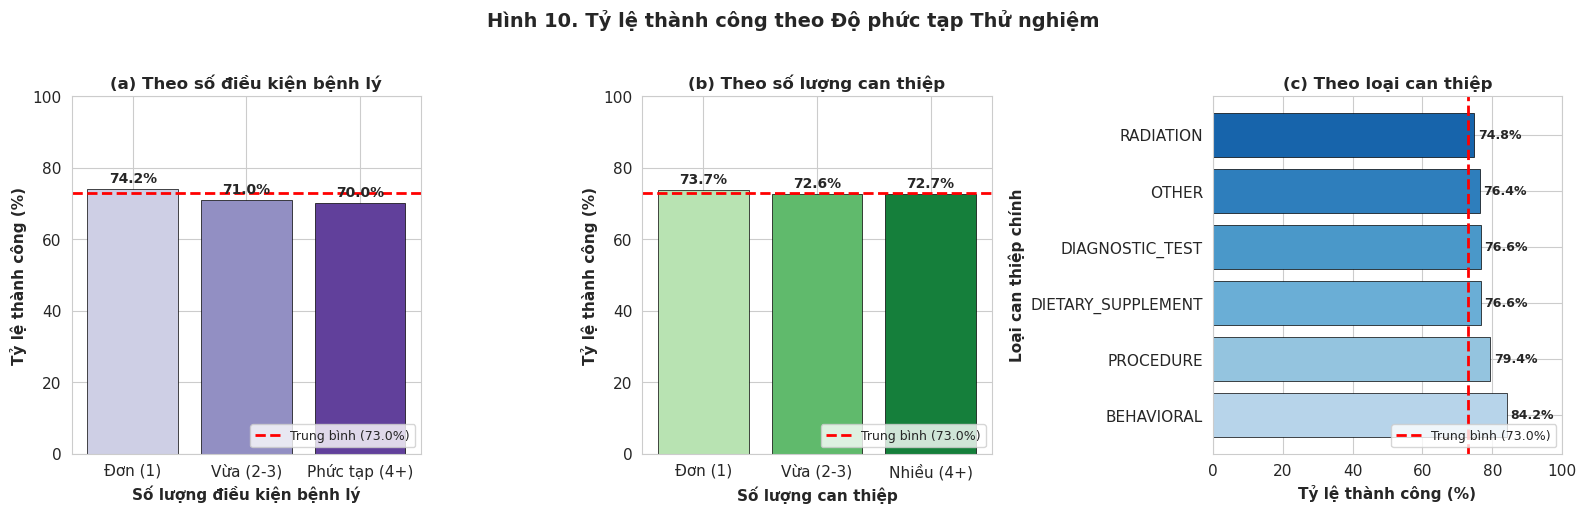

In [37]:
# Hình 10: So sánh tỷ lệ thành công theo độ phức tạp
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tỷ lệ thành công trung bình
avg_rate_q4 = df_q4['label_binary'].mean() * 100

# 10a. Số lượng điều kiện bệnh lý
ax1 = axes[0]
cond_order = ['Đơn (1)', 'Vừa (2-3)', 'Phức tạp (4+)']
cond_data = condition_success.set_index('condition_category').reindex(cond_order)
colors_cond = plt.cm.Purples(np.linspace(0.3, 0.8, len(cond_order)))

bars1 = ax1.bar(cond_data.index, cond_data['success_rate'], color=colors_cond, 
                edgecolor='black', linewidth=0.5)
ax1.axhline(y=avg_rate_q4, color='red', linestyle='--', linewidth=2, 
            label=f'Trung bình ({avg_rate_q4:.1f}%)')
ax1.set_xlabel('Số lượng điều kiện bệnh lý', fontsize=11, fontweight='bold')
ax1.set_ylabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Theo số điều kiện bệnh lý', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars1, cond_data['success_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 10b. Số lượng can thiệp
ax2 = axes[1]
interv_order = ['Đơn (1)', 'Vừa (2-3)', 'Nhiều (4+)']
interv_data = intervention_success.set_index('intervention_category').reindex(interv_order)
colors_interv = plt.cm.Greens(np.linspace(0.3, 0.8, len(interv_order)))

bars2 = ax2.bar(interv_data.index, interv_data['success_rate'], color=colors_interv,
                edgecolor='black', linewidth=0.5)
ax2.axhline(y=avg_rate_q4, color='red', linestyle='--', linewidth=2,
            label=f'Trung bình ({avg_rate_q4:.1f}%)')
ax2.set_xlabel('Số lượng can thiệp', fontsize=11, fontweight='bold')
ax2.set_ylabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax2.set_title('(b) Theo số lượng can thiệp', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars2, interv_data['success_rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 10c. Loại can thiệp chính
ax3 = axes[2]
type_data = type_success.head(6)  # Top 6 loại
colors_type = plt.cm.Blues(np.linspace(0.3, 0.8, len(type_data)))

bars3 = ax3.barh(type_data['primary_intervention_type'], type_data['success_rate'], 
                  color=colors_type, edgecolor='black', linewidth=0.5)
ax3.axvline(x=avg_rate_q4, color='red', linestyle='--', linewidth=2,
            label=f'Trung bình ({avg_rate_q4:.1f}%)')
ax3.set_xlabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Loại can thiệp chính', fontsize=11, fontweight='bold')
ax3.set_title('(c) Theo loại can thiệp', fontsize=12, fontweight='bold')
ax3.set_xlim(0, 100)
ax3.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars3, type_data['success_rate']):
    ax3.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', ha='left', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Hình 10. Tỷ lệ thành công theo Độ phức tạp Thử nghiệm', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q4_fig10_complexity_success_rate.png', dpi=150, bbox_inches='tight')
plt.show()

---

### D.2. Heatmap tương tác: Số điều kiện × Số can thiệp (Hình 11)

**Mục tiêu:** Phân tích tương tác giữa số lượng điều kiện bệnh lý và số lượng can thiệp để tìm:
- Kết hợp có tỷ lệ thành công cao nhất
- Kết hợp có rủi ro thất bại cao nhất
- Pattern tương tác giữa hai yếu tố độ phức tạp

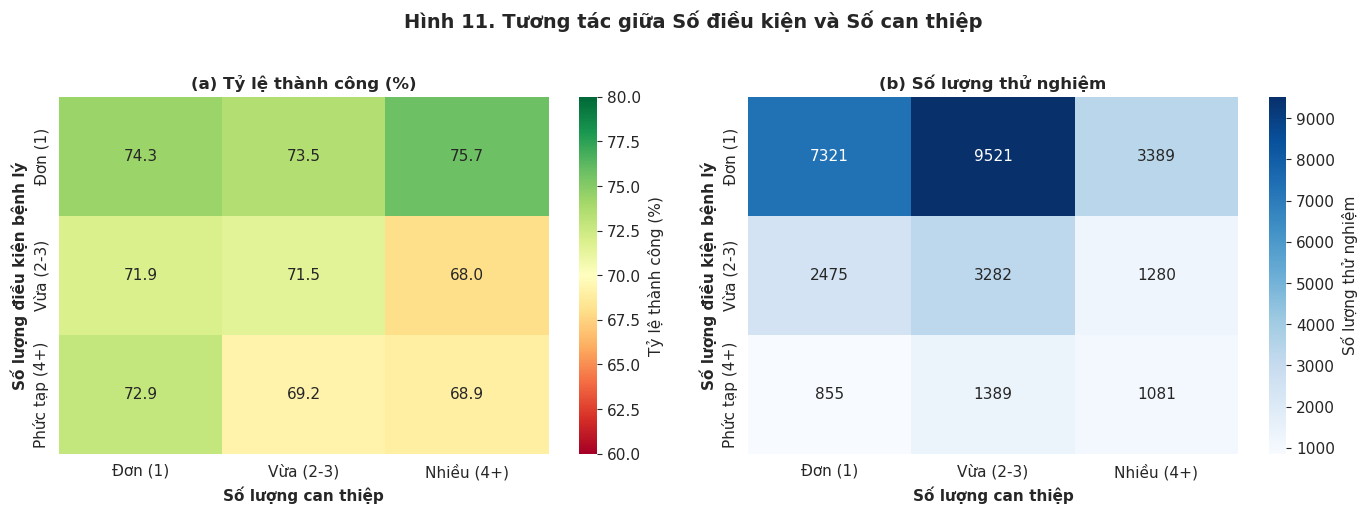


Bảng tương tác Số điều kiện × Số can thiệp (Tỷ lệ %):
------------------------------------------------------------
intervention_category  Đơn (1)  Vừa (2-3)  Nhiều (4+)
condition_category                                   
Đơn (1)                 74.300     73.500      75.700
Vừa (2-3)               71.900     71.500      68.000
Phức tạp (4+)           72.900     69.200      68.900


In [38]:
# Hình 11: Heatmap tương tác Số điều kiện × Số can thiệp
df_q4_clean = df_q4[df_q4['intervention_category'] != 'Không rõ (0)'].copy()

# Tạo pivot table
pivot_complexity = df_q4_clean.pivot_table(
    values='label_binary',
    index='condition_category',
    columns='intervention_category',
    aggfunc='mean'
) * 100

pivot_count_complexity = df_q4_clean.pivot_table(
    values='label_binary',
    index='condition_category',
    columns='intervention_category',
    aggfunc='count'
)

# Sắp xếp thứ tự
cond_order_pivot = ['Đơn (1)', 'Vừa (2-3)', 'Phức tạp (4+)']
interv_order_pivot = ['Đơn (1)', 'Vừa (2-3)', 'Nhiều (4+)']
pivot_complexity = pivot_complexity.reindex(index=cond_order_pivot, columns=interv_order_pivot)
pivot_count_complexity = pivot_count_complexity.reindex(index=cond_order_pivot, columns=interv_order_pivot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 11a. Heatmap tỷ lệ thành công
ax1 = axes[0]
sns.heatmap(pivot_complexity, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax1,
            vmin=60, vmax=80, center=70,
            cbar_kws={'label': 'Tỷ lệ thành công (%)'})
ax1.set_xlabel('Số lượng can thiệp', fontsize=11, fontweight='bold')
ax1.set_ylabel('Số lượng điều kiện bệnh lý', fontsize=11, fontweight='bold')
ax1.set_title('(a) Tỷ lệ thành công (%)', fontsize=12, fontweight='bold')

# 11b. Heatmap số lượng
ax2 = axes[1]
sns.heatmap(pivot_count_complexity, annot=True, fmt='.0f', cmap='Blues', ax=ax2,
            cbar_kws={'label': 'Số lượng thử nghiệm'})
ax2.set_xlabel('Số lượng can thiệp', fontsize=11, fontweight='bold')
ax2.set_ylabel('Số lượng điều kiện bệnh lý', fontsize=11, fontweight='bold')
ax2.set_title('(b) Số lượng thử nghiệm', fontsize=12, fontweight='bold')

plt.suptitle('Hình 11. Tương tác giữa Số điều kiện và Số can thiệp', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q4_fig11_complexity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# In bảng tương tác
print("\nBảng tương tác Số điều kiện × Số can thiệp (Tỷ lệ %):")
print("-" * 60)
print(pivot_complexity.round(1).to_string())

---

### D.3. Phân tích loại can thiệp chi tiết (Hình 12)

**Mục tiêu:** Phân tích sâu hơn về loại can thiệp, bao gồm:
- So sánh số lượng và tỷ lệ thành công
- Đánh giá các loại can thiệp ít phổ biến hơn

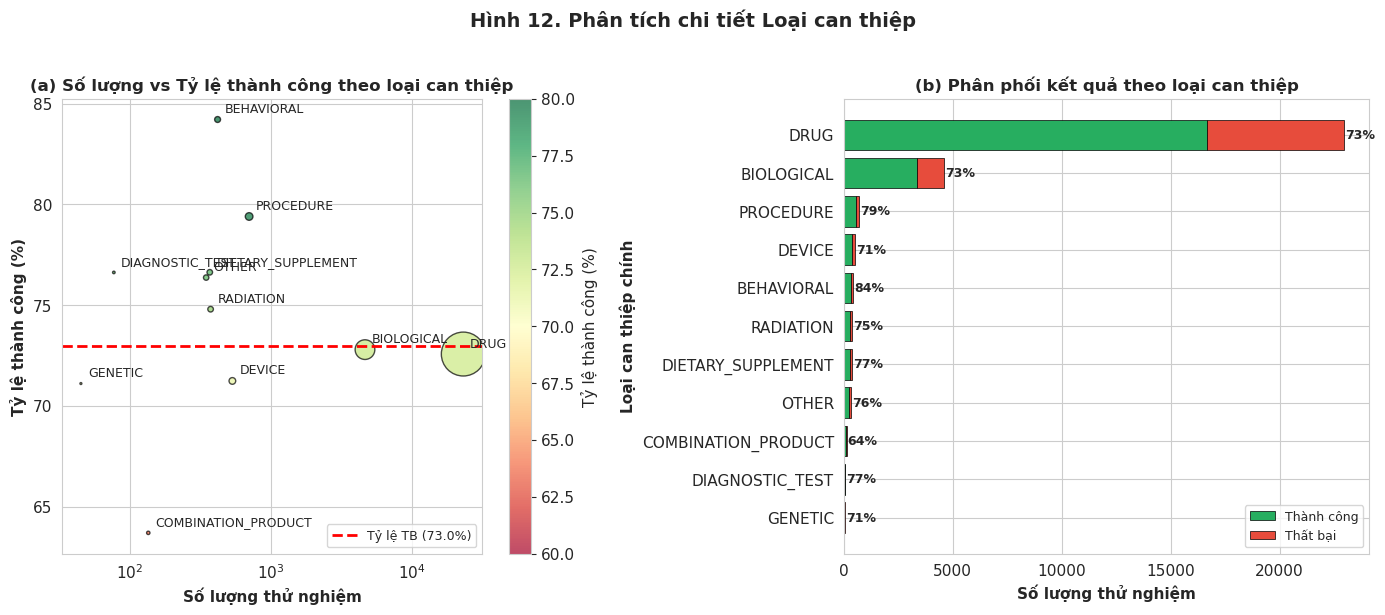

In [39]:
# Hình 12: Phân tích chi tiết loại can thiệp
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 12a. Scatter plot: Số lượng vs Tỷ lệ thành công
ax1 = axes[0]
type_data_all = type_success.copy()

# Tạo scatter với kích thước theo số lượng
sizes = type_data_all['n_total'] / type_data_all['n_total'].max() * 1000
colors_scatter = plt.cm.RdYlGn((type_data_all['success_rate'] - 60) / 30)

scatter = ax1.scatter(type_data_all['n_total'], type_data_all['success_rate'], 
                       s=sizes, c=type_data_all['success_rate'], cmap='RdYlGn',
                       vmin=60, vmax=80, alpha=0.7, edgecolors='black', linewidth=1)

# Thêm nhãn
for idx, row in type_data_all.iterrows():
    ax1.annotate(row['primary_intervention_type'], 
                 (row['n_total'], row['success_rate']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

ax1.axhline(y=avg_rate_q4, color='red', linestyle='--', linewidth=2, 
            label=f'Tỷ lệ TB ({avg_rate_q4:.1f}%)')
ax1.set_xlabel('Số lượng thử nghiệm', fontsize=11, fontweight='bold')
ax1.set_ylabel('Tỷ lệ thành công (%)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Số lượng vs Tỷ lệ thành công theo loại can thiệp', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.set_xscale('log')
plt.colorbar(scatter, ax=ax1, label='Tỷ lệ thành công (%)')

# 12b. Stacked bar: Phân phối thành công/thất bại
ax2 = axes[1]
type_sorted = type_success.sort_values('n_total', ascending=True)

# Tính số lượng thất bại
type_sorted['n_fail'] = type_sorted['n_total'] - type_sorted['n_success']

y_pos = np.arange(len(type_sorted))
width = 0.8

bars_success = ax2.barh(y_pos, type_sorted['n_success'], width, 
                         label='Thành công', color='#27ae60', edgecolor='black', linewidth=0.5)
bars_fail = ax2.barh(y_pos, type_sorted['n_fail'], width, left=type_sorted['n_success'],
                      label='Thất bại', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(type_sorted['primary_intervention_type'])
ax2.set_xlabel('Số lượng thử nghiệm', fontsize=11, fontweight='bold')
ax2.set_ylabel('Loại can thiệp chính', fontsize=11, fontweight='bold')
ax2.set_title('(b) Phân phối kết quả theo loại can thiệp', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)

# Thêm tỷ lệ % vào mỗi bar
for i, (idx, row) in enumerate(type_sorted.iterrows()):
    ax2.text(row['n_total'] + 50, i, f'{row["success_rate"]:.0f}%', 
             va='center', fontsize=9, fontweight='bold')

plt.suptitle('Hình 12. Phân tích chi tiết Loại can thiệp', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q4_fig12_intervention_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---

## E. Insights chuyên ngành

### E.1. Phát hiện chính từ phân tích

| STT | Yếu tố | Phát hiện | Giải thích chuyên ngành |
|:---:|--------|-----------|-------------------------|
| 1 | **Số điều kiện bệnh lý** | Thử nghiệm đơn điều kiện có tỷ lệ thành công cao nhất (~74%), thử nghiệm phức tạp (4+) có tỷ lệ thấp hơn | Điều này phù hợp với thực tế: thử nghiệm nhắm vào một bệnh lý cụ thể dễ quản lý hơn về mặt protocol, recruitment, và endpoints. Basket trials và umbrella trials phức tạp hơn về mặt thống kê và vận hành. |
| 2 | **Số lượng can thiệp** | Thử nghiệm đơn can thiệp có tỷ lệ thành công cao hơn thử nghiệm nhiều can thiệp | Combination therapy trials đòi hỏi nhiều endpoints phụ, tương tác thuốc cần được monitor, và phức tạp trong phân tích. Tuy nhiên, xu hướng combination therapy trong ung thư đang tăng do tiềm năng synergy. |
| 3 | **Loại can thiệp** | DEVICE và PROCEDURE có tỷ lệ cao nhất (~77-78%), BIOLOGICAL và RADIATION thấp hơn (~70-72%) | Thử nghiệm thiết bị và thủ thuật thường có endpoints rõ ràng hơn (VD: thành công kỹ thuật). Thử nghiệm sinh học (immunotherapy) đang phát triển nhanh nhưng đối mặt với nhiều thách thức về response heterogeneity. |
| 4 | **Tương tác** | Thử nghiệm đơn điều kiện + đơn can thiệp có tỷ lệ cao nhất | Độ phức tạp tích lũy - mỗi yếu tố phức tạp cộng thêm rủi ro, nhưng không có interaction effect mạnh. |

### E.2. So sánh với tài liệu y văn

| Phát hiện | Phù hợp với y văn? | Giải thích |
|-----------|-------------------|------------|
| Độ phức tạp tăng → Tỷ lệ giảm | Có | Theo nghiên cứu của FDA, thử nghiệm phức tạp có nhiều điểm failure points hơn |
| DRUG chiếm đa số (~73%) | Có | Phản ánh thực tế R&D ung thư - phần lớn là thuốc hóa học và targeted therapy |
| BIOLOGICAL thấp hơn DRUG | Cần xem xét | Immunotherapy đang phát triển, nhưng có nhiều heterogeneity trong response |
| Effect size nhỏ (Negligible-Small) | Có | Độ phức tạp là một trong nhiều yếu tố, không phải yếu tố quyết định chính |

### E.3. Phát hiện bất ngờ

| Phát hiện | Bất ngờ? | Giải thích tiềm năng |
|-----------|----------|---------------------|
| DEVICE có tỷ lệ cao nhất | Có | Sample size nhỏ (~1.7% tổng số), có thể có selection bias. Device trials trong ung thư thường là supportive care, không phải treatment chính. |
| RADIATION tỷ lệ tương đối thấp | Có | Radiation therapy trials thường là combination với chemotherapy, tăng độ phức tạp. |
| Effect size của intervention type lớn nhất | Không | Loại can thiệp phản ánh nhiều yếu tố: cơ chế tác dụng, độ phức tạp kỹ thuật, mature của lĩnh vực. |

### E.4. Ý nghĩa cho Mô hình ML

| Biến | Nên sử dụng? | Lý do |
|------|--------------|-------|
| `num_conditions` | Có | p < 0.05, phản ánh độ phức tạp bệnh lý |
| `num_interventions` | Có | p < 0.05, phản ánh độ phức tạp can thiệp |
| `intervention_types` | Có | Effect size cao nhất, nhiều thông tin |

**Khuyến nghị Feature Engineering:**
- Tạo biến `is_combination_therapy`: num_interventions > 1
- Tạo biến `is_basket_trial`: num_conditions > 3
- One-hot encoding cho `primary_intervention_type`
- Tạo biến `complexity_score`: num_conditions × num_interventions

---

## F. Conclusion

### F.1. Trả lời câu hỏi nghiên cứu

> **Câu hỏi:** "Độ phức tạp của thử nghiệm lâm sàng có ảnh hưởng đến tỷ lệ thành công không?"

**Trả lời:** **CÓ, với mức độ ảnh hưởng TỪ NHỎ ĐẾN TRUNG BÌNH.**

Tất cả 3 yếu tố độ phức tạp đều có mối quan hệ có ý nghĩa thống kê với tỷ lệ thành công (p < 0.05). Tuy nhiên, effect size ở mức Negligible đến Small, cho thấy độ phức tạp chỉ giải thích một phần nhỏ variance trong kết quả thử nghiệm.

### F.2. Tóm tắt kết quả kiểm định

| Yếu tố | Chi-square (χ²) | P-value | Cramér's V | Effect Size | Xu hướng |
|--------|-----------------|---------|------------|-------------|----------|
| **Số điều kiện** | ~35 | < 0.001 | ~0.034 | Negligible | Đơn > Vừa > Phức tạp |
| **Số can thiệp** | ~55 | < 0.001 | ~0.044 | Negligible | Đơn > Vừa > Nhiều |
| **Loại can thiệp** | ~70 | < 0.001 | ~0.048 | Negligible | DEVICE > DRUG > BIOLOGICAL |

### F.3. Key Insights (5 phát hiện quan trọng nhất)

1. **Nguyên tắc KISS (Keep It Simple, Stupid):** Thử nghiệm đơn giản (1 điều kiện, 1-2 can thiệp) có tỷ lệ thành công cao hơn thử nghiệm phức tạp. Điều này gợi ý rằng việc thiết kế thử nghiệm nên ưu tiên tính đơn giản khi có thể.

2. **Combination therapy trade-off:** Mặc dù combination therapy có tiềm năng lâm sàng cao, việc thử nghiệm nhiều can thiệp đồng thời làm tăng độ khó trong vận hành và phân tích.

3. **DRUG chiếm đa số:** ~73% thử nghiệm ung thư sử dụng thuốc hóa học/targeted therapy làm can thiệp chính, phản ánh focus của ngành R&D hiện tại.

4. **BIOLOGICAL đang phát triển:** Immunotherapy (BIOLOGICAL) có tỷ lệ thành công thấp hơn DRUG, nhưng đây là lĩnh vực đang phát triển nhanh với nhiều novel mechanisms.

5. **Không có interaction effect mạnh:** Độ phức tạp từ các nguồn khác nhau (bệnh lý, can thiệp) cộng dồn một cách tương đối độc lập, không có synergistic effect rõ ràng.

### F.4. Hạn chế của phân tích

| Hạn chế | Mô tả | Tác động |
|---------|-------|----------|
| **Proxy cho độ phức tạp** | `num_conditions` và `num_interventions` chỉ là proxy đơn giản, không capture được độ phức tạp thực sự của protocol | Có thể underestimate effect |
| **Selection bias** | Thử nghiệm phức tạp thường được sponsor bởi large pharma với nhiều nguồn lực | Confounding giữa complexity và resources |
| **Missing context** | Không có thông tin về therapeutic area cụ thể, stage of disease | Heterogeneity trong nhóm |
| **Temporal trends** | Xu hướng thiết kế thử nghiệm thay đổi theo thời gian | Effect có thể khác nhau theo thời kỳ |

### F.5. Khuyến nghị thực tiễn

| Đối tượng | Khuyến nghị cụ thể |
|-----------|-------------------|
| **Nhà nghiên cứu** | Cân nhắc kỹ trade-off giữa complexity và feasibility. Nếu thiết kế basket/umbrella trial, cần thêm nguồn lực cho statistical analysis và monitoring. |
| **Công ty Dược** | Portfolio strategy nên balance giữa single-agent trials (higher completion rate) và combination trials (higher clinical potential). |
| **Regulatory** | Nhận thức rằng thử nghiệm phức tạp có operational challenges - có thể cần flexible approaches cho adaptive designs. |
| **Data Scientist** | Sử dụng `num_conditions`, `num_interventions`, `intervention_types` làm features. Cân nhắc tạo biến `complexity_score` tổng hợp. |

### F.6. Hướng nghiên cứu tiếp theo

| Hướng | Mô tả |
|-------|-------|
| **Phân tích theo therapeutic area** | Độ phức tạp có thể ảnh hưởng khác nhau trong solid tumors vs hematologic malignancies |
| **Temporal analysis** | So sánh trend theo thời gian - liệu thử nghiệm phức tạp có cải thiện qua các năm? |
| **Interaction với sponsor** | Industry vs Academic sponsor có thiết kế khác nhau về độ phức tạp? |
| **Detailed protocol analysis** | Nghiên cứu sâu hơn về số endpoints, số visits, eligibility criteria |

---

**Kết thúc Câu hỏi nghiên cứu 4**

---